# 深大微堆参考模型计算与收敛性分析

本Notebook在不修改材料和几何定义的前提下，对参考假元件方案进行单次OpenMC验证。本轮使用刚完成的 `iaea_reference_v1` 几何，并把全部新结果写入独立目录；原 `legacy_simplified` screening结果只读、不覆盖。

本轮只运行一个 `screening` 算例，不运行 `final`，也不运行真实遗传算法。IAEA文献值只用于结果比较，不作为反向调整材料或几何参数的目标。


## 0 说明与环境加载

本节从已有材料、几何和优化Notebook的代码单元加载对象，不从`materials.py`或`geometry.py`导入。

为避免覆盖旧结果，加载器会跳过已有Notebook中的XML导出、OpenMC切片绘图和真实运行单元。特别是会跳过优化Notebook中使用`force_rerun=True`的旧debug试运行单元。

In [1]:
import sys
from numbers import Real
from pathlib import Path
from datetime import datetime
from typing import cast
import contextlib
import hashlib
import io
import json
import math
import xml.etree.ElementTree as ET

import h5py
import matplotlib.pyplot as plt
import numpy as np
import openmc
import pandas as pd
from IPython import get_ipython
from IPython.display import display

RUN_REAL_OPENMC_PILOT = False

~/.local/lib/python3.13/site-packages/openmc/config.py:110: UserWarning: Path '~/openmc_data/endf-b-vii.1-hdf5/cross_sections.xml' does not exist.
  warnings.warn(f"Path '{stored_path}' does not exist.", UserWarning)


In [2]:
def _execute_code(source, label):
    """在当前Jupyter内核执行一个已有Notebook代码单元。"""
    execution_result = get_ipython().run_cell(source)
    if execution_result.error_before_exec is not None:
        raise RuntimeError(
            f"加载{label}时发生执行前错误。"
        ) from execution_result.error_before_exec
    if execution_result.error_in_exec is not None:
        raise RuntimeError(
            f"加载{label}时发生运行错误。"
        ) from execution_result.error_in_exec


materials_notebook_path = Path("MNSR_materials_development.ipynb")
geometry_notebook_path = Path("MNSR_geometry_development.ipynb")
optimization_notebook_path = Path("MNSR_optimization_development.ipynb")

for notebook_path in (
    materials_notebook_path,
    geometry_notebook_path,
    optimization_notebook_path,
):
    if not notebook_path.is_file():
        raise FileNotFoundError(f"找不到已有Notebook：{notebook_path.resolve()}")

# 材料Notebook：执行材料定义和检查，跳过其项目级XML导出展示。
materials_notebook = json.loads(
    materials_notebook_path.read_text(encoding="utf-8")
)
for cell_index, cell in enumerate(materials_notebook["cells"]):
    if cell["cell_type"] != "code" or cell_index >= 31:
        continue
    _execute_code(
        "".join(cell["source"]),
        f"材料Notebook第{cell_index}单元",
    )

# 几何Notebook：材料已加载，因此跳过其材料加载单元；也跳过绘图与导出。
geometry_notebook = json.loads(
    geometry_notebook_path.read_text(encoding="utf-8")
)
geometry_skipped_cells = {3, 42, 44, 48, 50, 56, 58}
for cell_index, cell in enumerate(geometry_notebook["cells"]):
    if cell["cell_type"] != "code" or cell_index in geometry_skipped_cells:
        continue
    cell_source = "".join(cell["source"])
    if cell_index == 20:
        # 保留fuel/tie_rod/central行表，只跳过孔位图绘制和保存。
        cell_source = cell_source.split("figure, axis", 1)[0]
    elif cell_index == 46:
        # 只建立内存中的position_table，不写项目级position_table.csv。
        cell_source = cell_source.split("POSITION_TABLE_PATH", 1)[0]
    elif cell_index == 54:
        # 只加载已有参考方案常量，不执行两套几何导出验证。
        cell_source = cell_source.split(
            "global_component_types_before",
            1,
        )[0]
    _execute_code(
        cell_source,
        f"几何Notebook第{cell_index}单元",
    )

# 优化Notebook：只复用纯定义单元，跳过加载、debug导出/运行与结果绘图。
optimization_notebook = json.loads(
    optimization_notebook_path.read_text(encoding="utf-8")
)
optimization_definition_cells = {3, 5, 7, 9, 11, 13}
for cell_index, cell in enumerate(optimization_notebook["cells"]):
    if (
        cell["cell_type"] == "code"
        and cell_index in optimization_definition_cells
    ):
        _execute_code(
            "".join(cell["source"]),
            f"优化Notebook第{cell_index}单元",
        )

required_objects = {
    "materials",
    "material_map",
    "ordinary_positions_df",
    "position_table",
    "build_geometry_for_scheme",
    "REFERENCE_DUMMY_IDS",
    "create_power_tally",
    "RUN_PROFILES",
    "_prepare_evaluation_materials",
}
missing_objects = required_objects - set(globals())
assert not missing_objects, f"加载后缺少对象：{sorted(missing_objects)}"

Python解释器: ~/miniconda3/bin/python
OpenMC版本: 0.15.3.dev146+gc0f302db6
OpenMC安装位置: ~/.local/lib/python3.13/site-packages/openmc/__init__.py
使用的核数据库： ~/openmc_data/endfb-vii.1-hdf5/cross_sections.xml


找到的cross_sections.xml候选文件：
0 ~/openmc_data/endfb-vii.1-hdf5/cross_sections.xml
铀同位素原子份额：
U234: 0.002030905779
U235: 0.126389969504
U236: 0.002517072902
U238: 0.869062051815
铀原子份额之和： 1.0
U:O原子数比：1: 2.0
反算U-235铀内质量百分比： 12.499999999999998
燃料定义阶段捕获的警告： []
Zircaloy-4归一化质量份额： {'Zr': 0.9793000000000001, 'Sn': 0.017, 'Fe': 0.0024, 'Cr': 0.0013}
Al-303-1归一化质量份额： {'Al': 0.9777825791653787, 'Fe': 0.012003469002541733, 'Si': 0.010002890835451445, 'Cu': 5.0014454177257224e-05, 'Zn': 3.0008672506354334e-05, 'Mn': 3.0008672506354334e-05, 'Mg': 5.0014454177257224e-05, 'Ti': 5.0014454177257224e-05, 'B': 1.0002890835451446e-06}
LT-21归一化质量份额： {'Al': 0.981648, 'Si': 0.009000000000000001, 'Mg': 0.006750000000000001, 'Fe': 0.002, 'Ni': 0.0003, 'Cu': 0.0001, 'Mn': 0.0001, 'Ti': 0.0001, 'Cd': 1e-06, 'B': 1e-06}
SS-304归一化质量份额： {'Fe': 0.70845, 'Cr': 0.18, 'Ni': 0.08, 'Mn': 0.02, 'Si': 0.01, 'C': 0.0008, 'P': 0.00045, 'S': 0.0003}
轻水材料定义完成： Light Water
金属铍反射层材料定义完成： Beryllium Reflector
天然镉吸收体材料定义完成： Natural Cadm

,physical_position_id,ring_index,local_index,ring_radius_cm,theta_rad,theta_deg,x_cm,y_cm
0,0,0,0,0.000,0.000000,0.0,0.0000,0.000000e+00
1,1,1,0,1.095,0.000000,0.0,1.0950,0.000000e+00
2,2,1,1,1.095,1.047198,60.0,0.5475,9.482978e-01
3,3,1,2,1.095,2.094395,120.0,-0.5475,9.482978e-01
4,4,1,3,1.095,3.141593,180.0,-1.0950,1.340988e-16
5,5,1,4,1.095,4.188790,240.0,-0.5475,-9.482978e-01
6,6,1,5,1.095,5.235988,300.0,0.5475,-9.482978e-01
7,7,2,0,2.190,0.000000,0.0,2.1900,0.000000e+00


物理位置总数： 355
position_category
ordinary    350
tie_rod       4
central       1
Name: count, dtype: int64


,ordinary_position_id,physical_position_id,ring_index,local_index,ring_radius_cm,theta_rad,theta_deg,x_cm,y_cm,position_category
0,0,1,1,0,1.095,0.000000,0.0,1.0950,0.000000e+00,ordinary
1,1,2,1,1,1.095,1.047198,60.0,0.5475,9.482978e-01,ordinary
2,2,3,1,2,1.095,2.094395,120.0,-0.5475,9.482978e-01,ordinary
3,3,4,1,3,1.095,3.141593,180.0,-1.0950,1.340988e-16,ordinary
4,4,5,1,4,1.095,4.188790,240.0,-0.5475,-9.482978e-01,ordinary


...

,ordinary_position_id,ring_index,local_index,x_cm,y_cm
285,285,10,0,10.950000,0.000000
298,298,10,13,3.383736,10.414069
311,311,10,26,-8.858736,6.436249
324,324,10,39,-8.858736,-6.436249
337,337,10,52,3.383736,-10.414069


规范化参考假元件编号： (285, 298, 311, 324, 337)
有限轴向区域已建立。
堆芯外边界: 11.5 cm
侧铍内边界: 11.55 cm
侧铍外边界: 21.75 cm
容器内边界: 30.0 cm
容器外边界: 31.0 cm
控制棒状态： withdrawn
中央构件Cell数量： 2
燃料芯体Cell： 345
燃料包壳Cell： 345
假元件Cell： 5
连接杆Cell： 4
堆芯分圈水Cell数量： 11
内部分界半径（cm）： [0.71, 1.6425, 2.7375, 3.8325, 4.9275, 6.0225, 7.1175, 8.2125, 9.307500000000001, 10.4025]
外部结构Cell数量： 4
根宇宙Cell数量： 716
geometry.bounding_box lower_left： [-31.  -31.  -11.5]
geometry.bounding_box upper_right： [31.  31.  11.5]
几何数量和有限边界检查通过。


参考方案： (285, 298, 311, 324, 337)
参考方案稳定标识： 33a167859b1f


,particles,batches,inactive
debug,1000,20,5
screening,5000,60,15
final,20000,150,50


优化开发输出根目录： ~/SZU_MNSR_Opt/build/optimization


In [3]:
try:
    cross_sections_path = Path(
        openmc.config["cross_sections"]
    ).expanduser().resolve()
except KeyError as error:
    raise FileNotFoundError("尚未设置OpenMC截面库路径。") from error

if not cross_sections_path.is_file():
    raise FileNotFoundError(
        f"OpenMC截面库文件不存在：{cross_sections_path}"
    )
if tuple(REFERENCE_DUMMY_IDS) != (285, 298, 311, 324, 337):
    raise AssertionError("已有Notebook中的参考方案编号发生变化。")

print("Python解释器：", sys.executable)
print("OpenMC版本：", openmc.__version__)
print("截面库路径：", cross_sections_path)
print("参考方案编号：", REFERENCE_DUMMY_IDS)
print("当前真实GA pilot是否关闭：", not RUN_REAL_OPENMC_PILOT)

Python解释器： ~/miniconda3/bin/python
OpenMC版本： 0.15.3.dev146+gc0f302db6
截面库路径： ~/openmc_data/endfb-vii.1-hdf5/cross_sections.xml
参考方案编号： (285, 298, 311, 324, 337)
当前真实GA pilot是否关闭： True


## 1 读取已有debug参考结果

本节只读取`build/optimization/cases/33a167859b1f/`中的既有结果，不会重新运行debug，也不会改写该目录。

这些是低统计量流程检查结果，不是正式计算结果。

In [4]:
DEBUG_CASE_DIRECTORY = Path(
    "build/optimization/cases/33a167859b1f"
).resolve()
DEBUG_REQUIRED_FILES = {
    "result": DEBUG_CASE_DIRECTORY / "result.json",
    "statepoint": DEBUG_CASE_DIRECTORY / "statepoint.20.h5",
    "pin_power": DEBUG_CASE_DIRECTORY / "pin_power.csv",
    "scheme": DEBUG_CASE_DIRECTORY / "scheme.json",
    "settings": DEBUG_CASE_DIRECTORY / "settings.xml",
    "tallies": DEBUG_CASE_DIRECTORY / "tallies.xml",
}
missing_debug_files = [
    str(path)
    for path in DEBUG_REQUIRED_FILES.values()
    if not path.is_file()
]
if missing_debug_files:
    raise FileNotFoundError(
        "已有debug结果不完整；本Notebook不会自动重跑debug。缺少："
        + "；".join(missing_debug_files)
    )

debug_result = json.loads(
    DEBUG_REQUIRED_FILES["result"].read_text(encoding="utf-8")
)
debug_scheme = json.loads(
    DEBUG_REQUIRED_FILES["scheme"].read_text(encoding="utf-8")
)
debug_pin_power = pd.read_csv(DEBUG_REQUIRED_FILES["pin_power"])

if tuple(debug_scheme["dummy_position_ids"]) != tuple(REFERENCE_DUMMY_IDS):
    raise ValueError("已有debug方案不是当前参考假元件方案。")
if debug_result.get("status") != "completed":
    raise ValueError("已有debug结果状态不是completed。")
if len(debug_pin_power) != 345:
    raise ValueError(
        f"已有debug棒功率数据应为345行，实际为{len(debug_pin_power)}行。"
    )
if debug_pin_power["ordinary_position_id"].nunique() != 345:
    raise ValueError("已有debug棒功率孔位编号不完整或存在重复。")

debug_pin_power["relative_uncertainty"] = (
    debug_pin_power["kappa_fission_std"]
    / debug_pin_power["kappa_fission_mean"]
)
if not np.all(np.isfinite(debug_pin_power["relative_uncertainty"])):
    raise ValueError("已有debug棒功率相对误差含非有限值。")

In [5]:
debug_display = {
    "keff_mean": debug_result["keff_mean"],
    "keff_std": debug_result["keff_std"],
    "reactivity": debug_result["reactivity"],
    "radial_peaking_factor": debug_result["radial_peaking_factor"],
    "power_coefficient_of_variation": (
        debug_result["power_coefficient_of_variation"]
    ),
    "max_power_position_id": debug_result["max_power_position_id"],
    "complete_pin_count": len(debug_pin_power),
}
display(pd.Series(debug_display, name="debug低统计量结果"))
print("确认：未重新运行或改写已有debug目录。")

keff_mean                           0.869525
keff_std                            0.008309
reactivity                         -0.150053
radial_peaking_factor               1.715064
power_coefficient_of_variation      0.231723
max_power_position_id              70.000000
complete_pin_count                345.000000
Name: debug低统计量结果, dtype: float64

确认：未重新运行或改写已有debug目录。


## 2 IAEA参考几何与输入检查

这里显式调用 `model_variant="iaea_reference"`。检查对象包括355个物理位置、345根燃料元件、5根假元件、4根连接杆、撤出控制棒状态、外部池水有限边界，以及 `iaea_reference_v1` 几何版本标识。


In [6]:
reference_geometry, reference_geometry_metadata = build_geometry_for_scheme(
    REFERENCE_DUMMY_IDS,
    control_rod_state="withdrawn",
    export_directory=None,
    create_plots=False,
    model_variant="iaea_reference",
)

expected_counts = {
    "physical_positions": 355,
    "ordinary_positions": 350,
    "fuel": 345,
    "dummy": 5,
    "tie_rod": 4,
    "central": 1,
}
if reference_geometry_metadata["counts"] != expected_counts:
    raise AssertionError(
        "IAEA参考几何构件计数不一致："
        f"{reference_geometry_metadata['counts']}"
    )
if reference_geometry_metadata["control_rod_state"] != "withdrawn":
    raise AssertionError("参考计算必须使用控制棒完全拔出状态。")
if reference_geometry_metadata["model_variant"] != "iaea_reference":
    raise AssertionError("参考几何没有使用iaea_reference变体。")
if (
    reference_geometry_metadata["geometry_model_version"]
    != "iaea_reference_v1"
):
    raise AssertionError("参考几何版本不是iaea_reference_v1。")
if reference_geometry_metadata["top_be_thickness_cm"] != 0.0:
    raise AssertionError("初始IAEA参考模型不应启用顶部铍。")

lower_left = np.asarray(
    reference_geometry.bounding_box.lower_left,
    dtype=float,
)
upper_right = np.asarray(
    reference_geometry.bounding_box.upper_right,
    dtype=float,
)
if not np.all(np.isfinite([lower_left, upper_right])):
    raise AssertionError("IAEA参考几何bounding_box不是三方向有限。")

pool_bounds = reference_geometry_metadata["pool_bounds"]
expected_lower = np.asarray(
    [
        -pool_bounds["outer_radius_cm"],
        -pool_bounds["outer_radius_cm"],
        pool_bounds["z_bottom_cm"],
    ],
    dtype=float,
)
expected_upper = np.asarray(
    [
        pool_bounds["outer_radius_cm"],
        pool_bounds["outer_radius_cm"],
        pool_bounds["z_top_cm"],
    ],
    dtype=float,
)
if not (
    np.allclose(lower_left, expected_lower, atol=1.0e-12)
    and np.allclose(upper_right, expected_upper, atol=1.0e-12)
):
    raise AssertionError(
        "IAEA参考几何bounding_box与池水外边界不一致。"
    )

active_bounds = reference_geometry_metadata["active_fuel_bounds"]
if not (
    math.isclose(active_bounds["z_bottom_cm"], -11.5)
    and math.isclose(active_bounds["z_top_cm"], 11.5)
    and math.isclose(active_bounds["height_cm"], 23.0)
):
    raise AssertionError("活性燃料区轴向尺寸发生变化。")

vacuum_surfaces = [
    surface
    for surface in reference_geometry.get_all_surfaces().values()
    if surface.boundary_type == "vacuum"
]
if len(vacuum_surfaces) != 3:
    raise AssertionError(
        f"IAEA参考几何应只有3个池水真空边界，实际为{len(vacuum_surfaces)}。"
    )
vacuum_names = sorted(surface.name for surface in vacuum_surfaces)
if vacuum_names != sorted(
    reference_geometry_metadata["vacuum_boundary_names"]
):
    raise AssertionError("几何对象和metadata中的真空边界名称不一致。")

fuel_cell_names = [
    cell.name
    for cell in reference_geometry_metadata["fuel_meat_cells"]
]
if len(fuel_cell_names) != 345 or len(set(fuel_cell_names)) != 345:
    raise AssertionError("345个燃料芯体Cell名称不唯一。")

all_reference_cells = reference_geometry.get_all_cells().values()
if any(
    cell.fill is material_map["cadmium"]
    for cell in all_reference_cells
):
    raise AssertionError("withdrawn参考几何中不应存在镉吸收体。")

used_material_names = sorted({
    cell.fill.name
    for cell in reference_geometry.get_all_cells().values()
    if isinstance(cell.fill, openmc.Material)
})
if len(materials) != 8:
    raise AssertionError("统一材料库应包含8种材料对象。")
if not (
    math.isclose(R_CORE, 11.5)
    and math.isclose(R_BE_INNER, 11.55)
    and math.isclose(R_BE_OUTER, 21.75)
    and math.isclose(R_VESSEL_INNER, 30.0)
    and math.isclose(R_VESSEL_OUTER, 31.0)
):
    raise AssertionError("宏观径向边界与统一模型不一致。")

geometry_check = {
    **reference_geometry_metadata["counts"],
    "geometry_model_version": (
        reference_geometry_metadata["geometry_model_version"]
    ),
    "model_variant": reference_geometry_metadata["model_variant"],
    "control_rod_state": reference_geometry_metadata["control_rod_state"],
    "bounding_box_lower": lower_left.tolist(),
    "bounding_box_upper": upper_right.tolist(),
    "vacuum_boundary_count": len(vacuum_surfaces),
    "surface_count": len(reference_geometry.get_all_surfaces()),
    "defined_material_count": len(materials),
    "used_material_count": len(used_material_names),
    "used_material_names": used_material_names,
    "cadmium_present": False,
}
display(pd.Series(geometry_check, name="IAEA参考几何检查"))


physical_positions                                                      355
ordinary_positions                                                      350
fuel                                                                    345
dummy                                                                     5
tie_rod                                                                   4
central                                                                   1
geometry_model_version                                    iaea_reference_v1
model_variant                                                iaea_reference
control_rod_state                                                 withdrawn
bounding_box_lower                                  [-81.0, -81.0, -67.525]
bounding_box_upper                                     [81.0, 81.0, 61.925]
vacuum_boundary_count                                                     3
surface_count                                                           731
defined_mate

## 3 建立IAEA参考计算专用接口

新结果固定写入 `build/results/reference/iaea_reference_v1/screening/`。原 `build/results/reference/screening/` 被视为 `legacy_simplified` 结果，只读入用于比较。运行前记录旧目录及旧根目录结果文件的SHA-256，末尾再次检查，确保没有覆盖。


In [7]:
RESULTS_ROOT = Path("build/results/reference").resolve()
LEGACY_SCREENING_DIRECTORY = RESULTS_ROOT / "screening"
IAEA_GEOMETRY_MODEL_VERSION = "iaea_reference_v1"
IAEA_RESULTS_ROOT = RESULTS_ROOT / IAEA_GEOMETRY_MODEL_VERSION
SCREENING_DIRECTORY = IAEA_RESULTS_ROOT / "screening"
FINAL_DIRECTORY = IAEA_RESULTS_ROOT / "final"
SCREENING_DIRECTORY.mkdir(parents=True, exist_ok=True)

REFERENCE_RANDOM_SEED = 20260730
ALLOWED_REFERENCE_PROFILES = {"screening", "final"}
LITERATURE_KEFF = 1.005476


def _file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


LEGACY_RESULT_PATH = LEGACY_SCREENING_DIRECTORY / "result.json"
if not LEGACY_RESULT_PATH.is_file():
    raise FileNotFoundError(
        f"找不到原legacy screening结果：{LEGACY_RESULT_PATH}"
    )
legacy_screening_result = json.loads(
    LEGACY_RESULT_PATH.read_text(encoding="utf-8")
)
if legacy_screening_result.get("status") != "completed":
    raise ValueError("原legacy screening结果状态不是completed。")
if tuple(
    legacy_screening_result["reference_dummy_position_ids"]
) != tuple(REFERENCE_DUMMY_IDS):
    raise ValueError("原legacy screening使用的不是当前参考方案。")

legacy_protected_files = sorted(
    [
        path
        for path in LEGACY_SCREENING_DIRECTORY.rglob("*")
        if path.is_file()
    ]
    + [
        path
        for path in RESULTS_ROOT.iterdir()
        if path.is_file()
    ],
    key=lambda path: str(path),
)
LEGACY_PROTECTED_HASHES = {
    str(path.resolve()): _file_sha256(path)
    for path in legacy_protected_files
}

print("结果根目录：", RESULTS_ROOT)
print("只读legacy screening目录：", LEGACY_SCREENING_DIRECTORY)
print("新IAEA screening目录：", SCREENING_DIRECTORY)
print("final目录：", FINAL_DIRECTORY)
print("受SHA-256保护的旧结果文件数：", len(LEGACY_PROTECTED_HASHES))


结果根目录： ~/SZU_MNSR_Opt/build/results/reference
只读legacy screening目录： ~/SZU_MNSR_Opt/build/results/reference/screening
新IAEA screening目录： ~/SZU_MNSR_Opt/build/results/reference/iaea_reference_v1/screening
final目录： ~/SZU_MNSR_Opt/build/results/reference/iaea_reference_v1/final
受SHA-256保护的旧结果文件数： 19


## 4 参考计算Settings

`screening`和`final`参数直接来自已有`RUN_PROFILES`。初始源仍限制在可裂变材料附近，温度处理与优化Notebook保持一致，并记录固定随机种子。

Shannon熵网格只用于判断裂变源空间分布是否趋于稳定，不作为物理性能指标。

In [8]:
def create_reference_settings(
    profile_name,
    random_seed,
    enable_entropy=True,
):
    """创建参考模型screening/final本征值计算设置。"""
    if profile_name not in ALLOWED_REFERENCE_PROFILES:
        raise ValueError(
            "参考计算profile_name只允许'screening'或'final'。"
        )
    settings = create_settings(profile_name, random_seed)

    entropy_mesh = None
    if enable_entropy:
        entropy_mesh = openmc.RegularMesh(name="Reference entropy mesh")
        entropy_mesh.lower_left = (-11.5, -11.5, -11.5)
        entropy_mesh.upper_right = (11.5, 11.5, 11.5)
        entropy_mesh.dimension = (10, 10, 10)
        settings.entropy_mesh = entropy_mesh

    return settings, entropy_mesh


for profile_name in ("screening", "final"):
    profile = RUN_PROFILES[profile_name]
    print(profile_name, profile)
assert RUN_PROFILES["screening"] == {
    "particles": 5000,
    "batches": 60,
    "inactive": 15,
}
assert RUN_PROFILES["final"] == {
    "particles": 20000,
    "batches": 150,
    "inactive": 50,
}

screening {'particles': 5000, 'batches': 60, 'inactive': 15}
final {'particles': 20000, 'batches': 150, 'inactive': 50}


## 5 计数器

继续使用已有`create_power_tally`。计数器只包含345个燃料芯体Cell，score保持为`kappa-fission`，不增加三维Mesh Tally、完整通量或能谱。

In [9]:
reference_tallies, reference_fuel_cell_position_ids = create_power_tally(
    reference_geometry_metadata["fuel_meat_cells"]
)
reference_power_tally = reference_tallies[0]

if reference_power_tally.name != "fuel_pin_kappa_fission":
    raise AssertionError("功率Tally名称发生变化。")
if reference_power_tally.scores != ["kappa-fission"]:
    raise AssertionError("功率Tally只能包含kappa-fission score。")
if len(reference_power_tally.filters) != 1:
    raise AssertionError("功率Tally应只有一个CellFilter。")
if len(reference_power_tally.filters[0].bins) != 345:
    raise AssertionError("CellFilter没有包含345个燃料芯体Cell。")
if len(reference_fuel_cell_position_ids) != 345:
    raise AssertionError("燃料Cell与普通孔位映射不是345项。")
if len(set(reference_fuel_cell_position_ids)) != 345:
    raise AssertionError("燃料Cell孔位映射存在重复。")

print("Tally名称：", reference_power_tally.name)
print("score：", reference_power_tally.scores)
print("CellFilter燃料芯体数：", len(reference_power_tally.filters[0].bins))
print("未创建Mesh Tally、完整通量或能谱计数器。")

Tally名称： fuel_pin_kappa_fission
score： ['kappa-fission']
CellFilter燃料芯体数： 345
未创建Mesh Tally、完整通量或能谱计数器。


## 6 运行与日志保存

每个统计配置使用自己的目录。OpenMC标准输出通过Python重定向保存为`openmc_output.txt`，不依赖`openmc.out`。

若`result.json`已存在且`force_rerun=False`，函数直接读取缓存。失败时保存`error.json`并抛出中文异常，不生成虚假物理结果。

In [10]:
def _write_reference_json(path, payload):
    """保存UTF-8教学结果JSON。"""
    path.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


def _find_openmc_executable():
    """寻找与当前项目环境匹配的OpenMC可执行程序。"""
    candidates = [
        Path(sys.executable).with_name("openmc"),
        Path(sys.prefix) / "envs" / "openmc-env" / "bin" / "openmc",
    ]
    executable = next(
        (path.resolve() for path in candidates if path.is_file()),
        None,
    )
    if executable is None:
        raise FileNotFoundError(
            "找不到OpenMC可执行程序；不会伪造screening结果。"
        )
    return executable


def _prepare_reference_evaluation_materials(
    scheme_geometry,
    cross_sections_path,
    expected_beryllium_cell_count,
):
    """为含侧铍和底铍的IAEA几何建立评价材料集合。"""
    if (
        not isinstance(expected_beryllium_cell_count, int)
        or expected_beryllium_cell_count < 1
    ):
        raise ValueError("预期铍反射层Cell数量必须为正整数。")

    library_root = ET.parse(cross_sections_path).getroot()
    thermal_table_names = {
        library.get("materials")
        for library in library_root.findall("library")
        if library.get("type") == "thermal"
    }

    original_beryllium = material_map["beryllium"]
    beryllium_cells = [
        cell
        for cell in scheme_geometry.get_all_cells().values()
        if cell.fill is original_beryllium
    ]
    if len(beryllium_cells) != expected_beryllium_cell_count:
        raise RuntimeError(
            "IAEA几何中的铍反射层Cell数量不符合预期："
            f"预期{expected_beryllium_cell_count}，"
            f"实际{len(beryllium_cells)}。"
        )

    requested_table = "c_Be_in_Be"
    if requested_table in thermal_table_names:
        return materials, {}

    available_metal_be_table = "c_Be"
    if available_metal_be_table not in thermal_table_names:
        raise FileNotFoundError(
            "当前截面库既不含c_Be_in_Be，也不含可兼容的"
            "金属铍c_Be热散射表。"
        )

    evaluation_beryllium = openmc.Material(
        name=original_beryllium.name
    )
    for nuclide in original_beryllium.nuclides:
        evaluation_beryllium.add_nuclide(
            nuclide.name,
            nuclide.percent,
            nuclide.percent_type,
        )

    if original_beryllium.density is None:
        raise ValueError("原金属铍材料尚未设置密度。")
    evaluation_beryllium.set_density(
        original_beryllium.density_units,
        original_beryllium.density,
    )
    if original_beryllium.temperature is not None:
        evaluation_beryllium.temperature = cast(
            Real,
            original_beryllium.temperature,
        )
    evaluation_beryllium.add_s_alpha_beta(
        available_metal_be_table
    )

    for cell in beryllium_cells:
        cell.fill = evaluation_beryllium

    evaluation_materials = openmc.Materials([
        evaluation_beryllium
        if material is original_beryllium
        else material
        for material in materials
    ])
    aliases = {
        requested_table: available_metal_be_table,
    }
    return evaluation_materials, aliases


In [11]:
def evaluate_reference_profile(
    profile_name,
    force_rerun=False,
    enable_entropy=True,
):
    """在独立目录运行或读取参考模型screening/final结果。"""
    if profile_name not in ALLOWED_REFERENCE_PROFILES:
        raise ValueError(
            "profile_name只允许'screening'或'final'。"
        )
    if not isinstance(force_rerun, bool):
        raise ValueError("force_rerun必须是布尔值。")
    if not isinstance(enable_entropy, bool):
        raise ValueError("enable_entropy必须是布尔值。")

    run_directory = (
        SCREENING_DIRECTORY
        if profile_name == "screening"
        else FINAL_DIRECTORY
    )
    run_directory.mkdir(parents=True, exist_ok=True)
    result_path = run_directory / "result.json"
    error_path = run_directory / "error.json"
    output_path = run_directory / "openmc_output.txt"

    if result_path.is_file() and not force_rerun:
        return json.loads(result_path.read_text(encoding="utf-8"))

    try:
        if not cross_sections_path.is_file():
            raise FileNotFoundError(
                f"OpenMC截面库不存在：{cross_sections_path}"
            )

        scheme_geometry, geometry_metadata = build_geometry_for_scheme(
            REFERENCE_DUMMY_IDS,
            control_rod_state="withdrawn",
            export_directory=None,
            create_plots=False,
            model_variant="iaea_reference",
        )
        if (
            geometry_metadata.get("geometry_model_version")
            != IAEA_GEOMETRY_MODEL_VERSION
        ):
            raise RuntimeError(
                "构建结果的geometry_model_version不是"
                f"{IAEA_GEOMETRY_MODEL_VERSION}。"
            )
        if geometry_metadata.get("model_variant") != "iaea_reference":
            raise RuntimeError("构建结果不是iaea_reference几何变体。")
        evaluation_materials, thermal_scattering_aliases = (
            _prepare_reference_evaluation_materials(
                scheme_geometry,
                cross_sections_path,
                expected_beryllium_cell_count=(
                    2
                    + int(
                        geometry_metadata[
                            "top_be_thickness_cm"
                        ]
                        > 0.0
                    )
                ),
            )
        )
        settings, entropy_mesh = create_reference_settings(
            profile_name,
            REFERENCE_RANDOM_SEED,
            enable_entropy=enable_entropy,
        )
        tallies, fuel_cell_position_ids = create_power_tally(
            geometry_metadata["fuel_meat_cells"]
        )

        profile = RUN_PROFILES[profile_name]
        run_metadata = {
            "profile_name": profile_name,
            "geometry_model_version": IAEA_GEOMETRY_MODEL_VERSION,
            "model_variant": "iaea_reference",
            "reference_dummy_position_ids": list(REFERENCE_DUMMY_IDS),
            "control_rod_state": "withdrawn",
            "particles": profile["particles"],
            "batches": profile["batches"],
            "inactive": profile["inactive"],
            "random_seed": REFERENCE_RANDOM_SEED,
            "cross_sections": str(cross_sections_path),
            "enable_entropy": enable_entropy,
            "entropy_mesh": (
                None
                if entropy_mesh is None
                else {
                    "lower_left": list(entropy_mesh.lower_left),
                    "upper_right": list(entropy_mesh.upper_right),
                    "dimension": list(entropy_mesh.dimension),
                }
            ),
            "thermal_scattering_aliases": thermal_scattering_aliases,
            "created_at": datetime.now().isoformat(),
        }
        _write_reference_json(
            run_directory / "run_metadata.json",
            run_metadata,
        )

        model = openmc.Model()
        model.materials = evaluation_materials
        model.geometry = scheme_geometry
        model.settings = settings
        model.tallies = tallies
        model.export_to_xml(directory=run_directory)

        required_xml_files = [
            run_directory / "materials.xml",
            run_directory / "geometry.xml",
            run_directory / "settings.xml",
            run_directory / "tallies.xml",
        ]
        if not all(path.is_file() for path in required_xml_files):
            raise RuntimeError("参考计算XML导出不完整。")

        openmc_executable = _find_openmc_executable()
        output_buffer = io.StringIO()
        from unittest.mock import PropertyMock, patch

        try:
            with (
                contextlib.redirect_stdout(output_buffer),
                contextlib.redirect_stderr(output_buffer),
                patch.object(
                    openmc.Model,
                    "is_initialized",
                    new_callable=PropertyMock,
                    return_value=False,
                ),
            ):
                returned_statepoint = model.run(
                    cwd=run_directory,
                    openmc_exec=openmc_executable,
                    export_model_xml=False,
                )
        finally:
            output_path.write_text(
                output_buffer.getvalue(),
                encoding="utf-8",
            )

        if returned_statepoint is None:
            statepoint_candidates = sorted(
                run_directory.glob("statepoint.*.h5")
            )
            if not statepoint_candidates:
                raise FileNotFoundError(
                    "OpenMC运行完成后未找到statepoint文件。"
                )
            statepoint_path = statepoint_candidates[-1]
        else:
            statepoint_path = Path(returned_statepoint)
            if not statepoint_path.is_absolute():
                statepoint_path = run_directory / statepoint_path
        statepoint_path = statepoint_path.resolve()
        if not statepoint_path.is_file():
            raise FileNotFoundError(
                f"statepoint文件不存在：{statepoint_path}"
            )

        statepoint_data = _read_reference_statepoint(
            statepoint_path,
            require_entropy=enable_entropy,
        )
        pin_values = statepoint_data["pin_values"]
        pin_std_values = statepoint_data["pin_std_values"]
        if pin_values.size != 345 or pin_std_values.size != 345:
            raise ValueError(
                "功率Tally维数不符合345根燃料元件："
                f"mean={pin_values.size}, std={pin_std_values.size}。"
            )
        if (
            not np.all(np.isfinite(pin_values))
            or not np.all(np.isfinite(pin_std_values))
            or np.any(pin_values <= 0.0)
        ):
            raise ValueError(
                "kappa-fission均值/标准差含非有限值或非正均值。"
            )

        mean_pin_power = float(np.mean(pin_values))
        relative_power = pin_values / mean_pin_power
        relative_uncertainty = pin_std_values / pin_values
        if not np.all(np.isfinite(relative_uncertainty)):
            raise ValueError("棒功率相对统计误差含非有限值。")

        pin_power_table = pd.DataFrame({
            "ordinary_position_id": fuel_cell_position_ids,
            "kappa_fission_mean": pin_values,
            "kappa_fission_std": pin_std_values,
            "relative_power": relative_power,
            "relative_uncertainty": relative_uncertainty,
        }).merge(
            ordinary_positions_df[[
                "ordinary_position_id",
                "ring_index",
                "local_index",
                "x_cm",
                "y_cm",
            ]],
            on="ordinary_position_id",
            how="left",
            validate="one_to_one",
        )
        pin_power_table = pin_power_table[[
            "ordinary_position_id",
            "ring_index",
            "local_index",
            "x_cm",
            "y_cm",
            "kappa_fission_mean",
            "kappa_fission_std",
            "relative_power",
            "relative_uncertainty",
        ]]
        pin_power_path = run_directory / "pin_power.csv"
        pin_power_table.to_csv(
            pin_power_path,
            index=False,
            encoding="utf-8",
        )

        generation_values = statepoint_data["k_generation"]
        generation_history = pd.DataFrame({
            "batch": np.arange(1, generation_values.size + 1),
            "phase": np.where(
                np.arange(1, generation_values.size + 1)
                <= profile["inactive"],
                "inactive",
                "active",
            ),
            "k_generation": generation_values,
        })
        generation_history_path = (
            run_directory / "generation_history.csv"
        )
        generation_history.to_csv(
            generation_history_path,
            index=False,
            encoding="utf-8",
        )

        entropy_values = statepoint_data["entropy"]
        entropy_history_path = run_directory / "entropy_history.csv"
        if entropy_values is None:
            raise RuntimeError(
                "statepoint没有Shannon熵数据；未伪造entropy_history.csv。"
            )
        entropy_history = pd.DataFrame({
            "batch": np.arange(1, entropy_values.size + 1),
            "phase": np.where(
                np.arange(1, entropy_values.size + 1)
                <= profile["inactive"],
                "inactive",
                "active",
            ),
            "shannon_entropy": entropy_values,
        })
        entropy_history.to_csv(
            entropy_history_path,
            index=False,
            encoding="utf-8",
        )

        keff_mean = statepoint_data["keff_mean"]
        keff_std = statepoint_data["keff_std"]
        reactivity = (keff_mean - 1.0) / keff_mean
        reactivity_std_approx = keff_std / (keff_mean ** 2)
        max_index = int(np.argmax(pin_values))
        result = {
            "profile_name": profile_name,
            "status": "completed",
            "geometry_model_version": IAEA_GEOMETRY_MODEL_VERSION,
            "model_variant": "iaea_reference",
            "reference_dummy_position_ids": list(REFERENCE_DUMMY_IDS),
            "particles": profile["particles"],
            "batches": profile["batches"],
            "inactive": profile["inactive"],
            "random_seed": REFERENCE_RANDOM_SEED,
            "keff_mean": float(keff_mean),
            "keff_std": float(keff_std),
            "reactivity": float(reactivity),
            "reactivity_std_approx": float(reactivity_std_approx),
            "radial_peaking_factor": float(np.max(relative_power)),
            "power_coefficient_of_variation": float(
                np.std(pin_values, ddof=0) / mean_pin_power
            ),
            "max_power_position_id": int(
                fuel_cell_position_ids[max_index]
            ),
            "mean_pin_relative_uncertainty": float(
                np.mean(relative_uncertainty)
            ),
            "median_pin_relative_uncertainty": float(
                np.median(relative_uncertainty)
            ),
            "p95_pin_relative_uncertainty": float(
                np.quantile(relative_uncertainty, 0.95)
            ),
            "max_pin_relative_uncertainty": float(
                np.max(relative_uncertainty)
            ),
            "statepoint_file": str(statepoint_path),
            "pin_power_file": str(pin_power_path.resolve()),
            "generation_history_file": str(
                generation_history_path.resolve()
            ),
            "entropy_history_file": str(
                entropy_history_path.resolve()
            ),
            "openmc_output_file": str(output_path.resolve()),
            "run_directory": str(run_directory),
            "thermal_scattering_aliases": thermal_scattering_aliases,
        }
        _write_reference_json(result_path, result)
        error_path.unlink(missing_ok=True)
        return result

    except Exception as error:
        error_payload = {
            "profile_name": profile_name,
            "geometry_model_version": IAEA_GEOMETRY_MODEL_VERSION,
            "model_variant": "iaea_reference",
            "reference_dummy_position_ids": list(REFERENCE_DUMMY_IDS),
            "error_type": type(error).__name__,
            "error_message": str(error),
            "timestamp": datetime.now().isoformat(),
        }
        _write_reference_json(error_path, error_payload)
        raise RuntimeError(
            f"{profile_name}参考计算失败；错误记录：{error_path}；"
            f"原因：{error}"
        ) from error

## 7 状态点读取

优先使用OpenMC Python API读取`keff`、`k_generation`和Shannon熵。若当前API不能直接读取熵，则使用`h5py`读取statepoint根目录中的`entropy`数据集；若数据确实不存在则报错，绝不伪造。

In [12]:
def _read_reference_statepoint(
    statepoint_path,
    require_entropy=True,
):
    """读取参考计算的keff历史、熵和345棒kappa-fission。"""
    entropy_values = None
    with openmc.StatePoint(statepoint_path) as statepoint:
        keff = statepoint.keff
        keff_mean = float(keff.nominal_value)
        keff_std = float(keff.std_dev)
        k_generation = np.asarray(
            statepoint.k_generation,
            dtype=float,
        ).reshape(-1)
        try:
            entropy_values = np.asarray(
                statepoint.entropy,
                dtype=float,
            ).reshape(-1)
        except (AttributeError, KeyError):
            entropy_values = None

        power_tally = statepoint.get_tally(
            name="fuel_pin_kappa_fission"
        )
        pin_values = np.asarray(
            power_tally.mean,
            dtype=float,
        ).reshape(-1)
        pin_std_values = np.asarray(
            power_tally.std_dev,
            dtype=float,
        ).reshape(-1)

    if entropy_values is None:
        with h5py.File(statepoint_path, "r") as statepoint_h5:
            if "entropy" in statepoint_h5:
                entropy_values = np.asarray(
                    statepoint_h5["entropy"][...],
                    dtype=float,
                ).reshape(-1)

    if require_entropy and entropy_values is None:
        raise KeyError(
            "当前statepoint既不能通过OpenMC API读取entropy，"
            "也不存在HDF5 entropy数据集。"
        )
    if not np.all(np.isfinite(k_generation)):
        raise ValueError("k_generation包含非有限值。")
    if entropy_values is not None and not np.all(
        np.isfinite(entropy_values)
    ):
        raise ValueError("Shannon熵历史包含非有限值。")

    return {
        "keff_mean": keff_mean,
        "keff_std": keff_std,
        "k_generation": k_generation,
        "entropy": entropy_values,
        "pin_values": pin_values,
        "pin_std_values": pin_std_values,
    }

## 8 单次IAEA screening运行控制

`RUN_SCREENING_REFERENCE=True` 只允许运行（或读取缓存）一个 `iaea_reference_v1` screening参考算例。新目录首次不存在时实际运行一次；之后再次Run All会读取 `result.json`，不会重复计算。`final`和真实遗传算法开关保持关闭。


In [13]:
RUN_SCREENING_REFERENCE = True
RUN_FINAL_REFERENCE = False
RUN_REAL_GA = False

if RUN_FINAL_REFERENCE:
    raise RuntimeError("本轮禁止运行final配置。")
if RUN_REAL_GA:
    raise RuntimeError("本轮禁止运行真实遗传算法。")

if RUN_SCREENING_REFERENCE:
    screening_result = evaluate_reference_profile(
        "screening",
        force_rerun=False,
        enable_entropy=True,
    )
else:
    screening_result_path = SCREENING_DIRECTORY / "result.json"
    if not screening_result_path.is_file():
        raise FileNotFoundError(
            "screening开关关闭且没有iaea_reference_v1缓存结果。"
        )
    screening_result = json.loads(
        screening_result_path.read_text(encoding="utf-8")
    )

if screening_result.get("status") != "completed":
    raise RuntimeError("IAEA screening结果状态不是completed。")
if (
    screening_result.get("geometry_model_version")
    != IAEA_GEOMETRY_MODEL_VERSION
):
    raise RuntimeError("screening结果几何版本标识不正确。")
if screening_result.get("model_variant") != "iaea_reference":
    raise RuntimeError("screening结果几何变体标识不正确。")
if Path(screening_result["run_directory"]).resolve() != (
    SCREENING_DIRECTORY.resolve()
):
    raise RuntimeError("screening结果目录不是指定的IAEA独立目录。")

print("IAEA screening参考计算状态：", screening_result["status"])
print("几何版本：", screening_result["geometry_model_version"])
print("运行目录：", screening_result["run_directory"])
print("本轮final运行：", RUN_FINAL_REFERENCE)
print("本轮真实GA运行：", RUN_REAL_GA)


IAEA screening参考计算状态： completed
几何版本： iaea_reference_v1
运行目录： ~/SZU_MNSR_Opt/build/results/reference/iaea_reference_v1/screening
本轮final运行： False
本轮真实GA运行： False


## 9 收敛结果图

以下图表只描述`screening`统计量结果，不称为最终功率分布或论文最终计算。

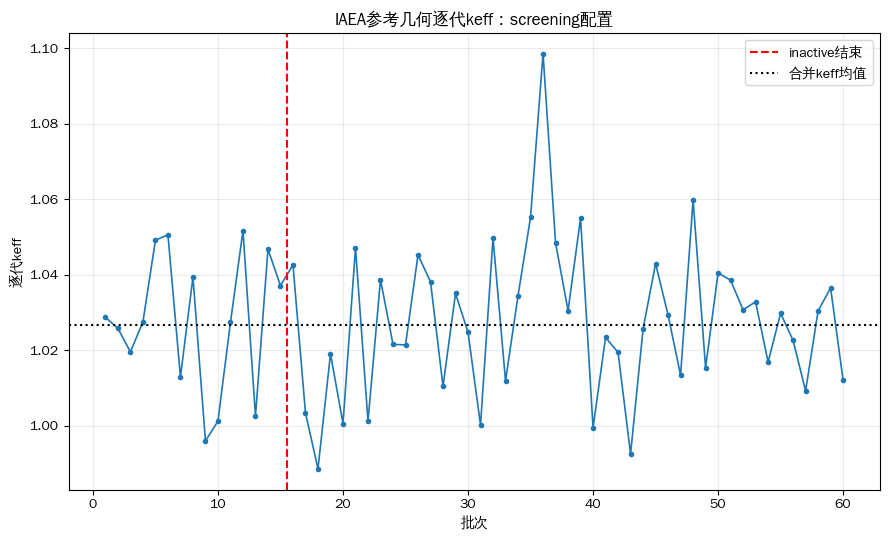

In [14]:
screening_generation_history = pd.read_csv(
    screening_result["generation_history_file"]
)
inactive_batches = RUN_PROFILES["screening"]["inactive"]

keff_figure, keff_axis = plt.subplots(figsize=(9, 5.5))
keff_axis.plot(
    screening_generation_history["batch"],
    screening_generation_history["k_generation"],
    marker="o",
    markersize=3,
    linewidth=1.2,
)
keff_axis.axvline(
    inactive_batches + 0.5,
    color="red",
    linestyle="--",
    label="inactive结束",
)
keff_axis.axhline(
    screening_result["keff_mean"],
    color="black",
    linestyle=":",
    label="合并keff均值",
)
keff_axis.set_xlabel("批次")
keff_axis.set_ylabel("逐代keff")
keff_axis.set_title("IAEA参考几何逐代keff：screening配置")
keff_axis.grid(alpha=0.25)
keff_axis.legend()
keff_figure.tight_layout()
KEFF_PLOT_PATH = SCREENING_DIRECTORY / "keff_generation_screening.png"
keff_figure.savefig(KEFF_PLOT_PATH, dpi=180, bbox_inches="tight")
plt.show()

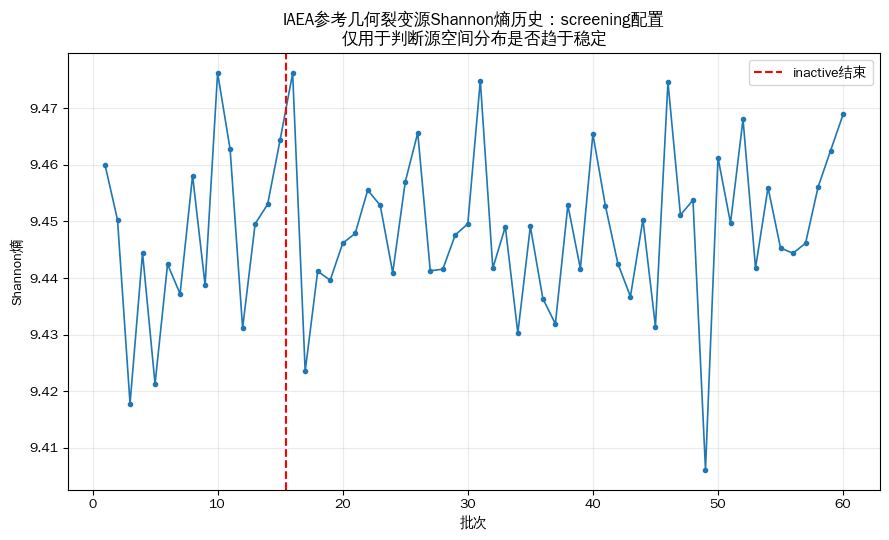

In [15]:
screening_entropy_history = pd.read_csv(
    screening_result["entropy_history_file"]
)
entropy_figure, entropy_axis = plt.subplots(figsize=(9, 5.5))
entropy_axis.plot(
    screening_entropy_history["batch"],
    screening_entropy_history["shannon_entropy"],
    marker="o",
    markersize=3,
    linewidth=1.2,
)
entropy_axis.axvline(
    inactive_batches + 0.5,
    color="red",
    linestyle="--",
    label="inactive结束",
)
entropy_axis.set_xlabel("批次")
entropy_axis.set_ylabel("Shannon熵")
entropy_axis.set_title(
    "IAEA参考几何裂变源Shannon熵历史：screening配置\n"
    "仅用于判断源空间分布是否趋于稳定"
)
entropy_axis.grid(alpha=0.25)
entropy_axis.legend()
entropy_figure.tight_layout()
ENTROPY_PLOT_PATH = SCREENING_DIRECTORY / "shannon_entropy_screening.png"
entropy_figure.savefig(
    ENTROPY_PLOT_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

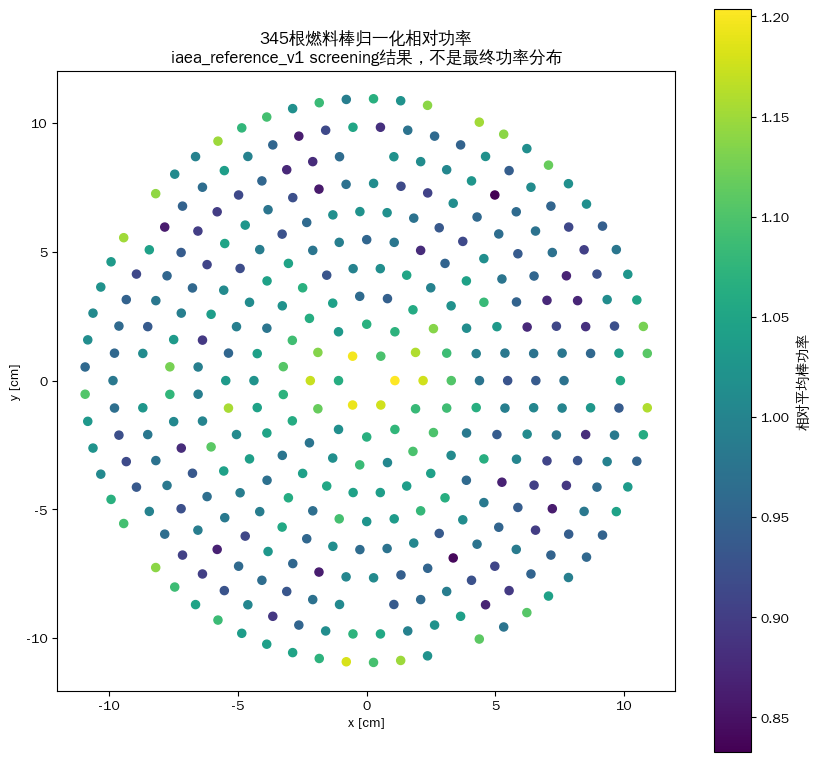

In [16]:
screening_pin_power = pd.read_csv(screening_result["pin_power_file"])
if len(screening_pin_power) != 345:
    raise AssertionError("screening棒功率数据不是345行。")

pin_figure, pin_axis = plt.subplots(figsize=(8.5, 7.8))
pin_scatter = pin_axis.scatter(
    screening_pin_power["x_cm"],
    screening_pin_power["y_cm"],
    c=screening_pin_power["relative_power"],
    s=34,
    cmap="viridis",
)
pin_axis.set_aspect("equal")
pin_axis.set_xlabel("x [cm]")
pin_axis.set_ylabel("y [cm]")
pin_axis.set_title(
    "345根燃料棒归一化相对功率\n"
    "iaea_reference_v1 screening结果，不是最终功率分布"
)
pin_colorbar = pin_figure.colorbar(pin_scatter, ax=pin_axis)
pin_colorbar.set_label("相对平均棒功率")
pin_figure.tight_layout()
PIN_POWER_PLOT_PATH = SCREENING_DIRECTORY / "pin_power_screening.png"
pin_figure.savefig(
    PIN_POWER_PLOT_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

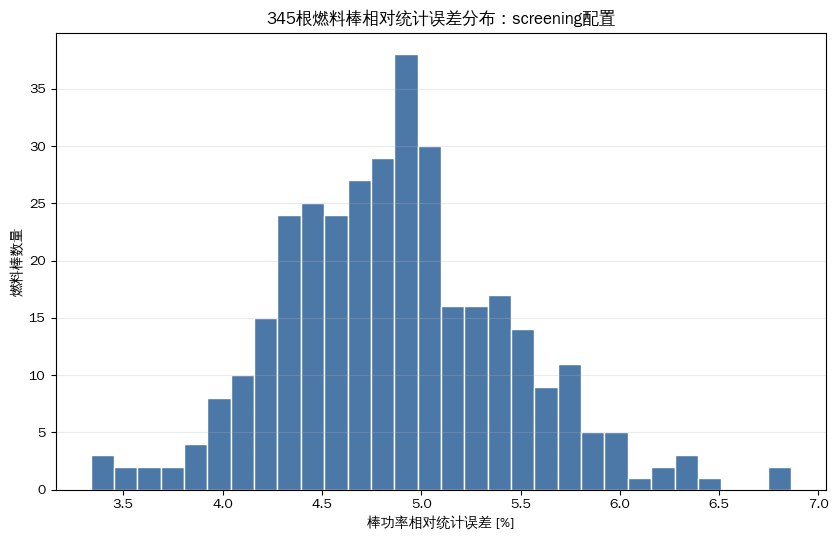

In [17]:
uncertainty_figure, uncertainty_axis = plt.subplots(figsize=(8.5, 5.5))
uncertainty_axis.hist(
    100.0 * screening_pin_power["relative_uncertainty"],
    bins=30,
    color="#4c78a8",
    edgecolor="white",
)
uncertainty_axis.set_xlabel("棒功率相对统计误差 [%]")
uncertainty_axis.set_ylabel("燃料棒数量")
uncertainty_axis.set_title(
    "345根燃料棒相对统计误差分布：screening配置"
)
uncertainty_axis.grid(axis="y", alpha=0.25)
uncertainty_figure.tight_layout()
PIN_UNCERTAINTY_PLOT_PATH = (
    SCREENING_DIRECTORY / "pin_relative_uncertainty_histogram.png"
)
uncertainty_figure.savefig(
    PIN_UNCERTAINTY_PLOT_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## 10 legacy与iaea_reference结果对比

这里读取原有 `legacy_simplified` screening结果，与本次 `iaea_reference_v1` 结果按相同字段比较。两行都使用同一个IAEA参考值 `1.005476` 计算差异；该参考值不参与调参。


In [18]:
def _pin_uncertainty_statistics(table):
    values = table["relative_uncertainty"].to_numpy(dtype=float)
    return {
        "mean_pin_relative_uncertainty": float(np.mean(values)),
        "median_pin_relative_uncertainty": float(np.median(values)),
        "p95_pin_relative_uncertainty": float(
            np.quantile(values, 0.95)
        ),
        "max_pin_relative_uncertainty": float(np.max(values)),
    }


legacy_pin_power = pd.read_csv(
    legacy_screening_result["pin_power_file"]
)
if len(legacy_pin_power) != 345:
    raise AssertionError("原legacy棒功率数据不是345行。")
if "relative_uncertainty" not in legacy_pin_power:
    legacy_pin_power["relative_uncertainty"] = (
        legacy_pin_power["kappa_fission_std"]
        / legacy_pin_power["kappa_fission_mean"]
    )

legacy_uncertainty_statistics = _pin_uncertainty_statistics(
    legacy_pin_power
)
debug_uncertainty_statistics = _pin_uncertainty_statistics(
    debug_pin_power
)
screening_uncertainty_statistics = _pin_uncertainty_statistics(
    screening_pin_power
)
keff_change_from_legacy = (
    screening_result["keff_mean"]
    - legacy_screening_result["keff_mean"]
)

geometry_comparison_rows = [
    {
        "model_variant": "legacy_simplified",
        "keff_mean": legacy_screening_result["keff_mean"],
        "keff_std": legacy_screening_result["keff_std"],
        "reactivity": legacy_screening_result["reactivity"],
        "radial_peaking_factor": legacy_screening_result[
            "radial_peaking_factor"
        ],
        "power_coefficient_of_variation": legacy_screening_result[
            "power_coefficient_of_variation"
        ],
        "median_pin_relative_uncertainty": (
            legacy_uncertainty_statistics[
                "median_pin_relative_uncertainty"
            ]
        ),
        "keff_difference_from_literature": (
            legacy_screening_result["keff_mean"] - LITERATURE_KEFF
        ),
        "keff_change_from_legacy": 0.0,
        "run_directory": str(LEGACY_SCREENING_DIRECTORY),
    },
    {
        "model_variant": "iaea_reference",
        "keff_mean": screening_result["keff_mean"],
        "keff_std": screening_result["keff_std"],
        "reactivity": screening_result["reactivity"],
        "radial_peaking_factor": screening_result[
            "radial_peaking_factor"
        ],
        "power_coefficient_of_variation": screening_result[
            "power_coefficient_of_variation"
        ],
        "median_pin_relative_uncertainty": (
            screening_uncertainty_statistics[
                "median_pin_relative_uncertainty"
            ]
        ),
        "keff_difference_from_literature": (
            screening_result["keff_mean"] - LITERATURE_KEFF
        ),
        "keff_change_from_legacy": keff_change_from_legacy,
        "run_directory": str(SCREENING_DIRECTORY),
    },
]
geometry_revision_comparison = pd.DataFrame(
    geometry_comparison_rows
)
GEOMETRY_REVISION_COMPARISON_PATH = (
    SCREENING_DIRECTORY / "geometry_revision_comparison.csv"
)
geometry_revision_comparison.to_csv(
    GEOMETRY_REVISION_COMPARISON_PATH,
    index=False,
    encoding="utf-8",
)

comparison_rows = [
    {
        "profile": "debug_legacy",
        **RUN_PROFILES["debug"],
        "keff_mean": debug_result["keff_mean"],
        "keff_std": debug_result["keff_std"],
        "reactivity": debug_result["reactivity"],
        "radial_peaking_factor": debug_result[
            "radial_peaking_factor"
        ],
        "power_coefficient_of_variation": debug_result[
            "power_coefficient_of_variation"
        ],
        **debug_uncertainty_statistics,
        "status": debug_result["status"],
    },
    {
        "profile": "screening_iaea_reference_v1",
        **RUN_PROFILES["screening"],
        "keff_mean": screening_result["keff_mean"],
        "keff_std": screening_result["keff_std"],
        "reactivity": screening_result["reactivity"],
        "radial_peaking_factor": screening_result[
            "radial_peaking_factor"
        ],
        "power_coefficient_of_variation": screening_result[
            "power_coefficient_of_variation"
        ],
        **screening_uncertainty_statistics,
        "status": screening_result["status"],
    },
]
reference_convergence_summary = pd.DataFrame(comparison_rows)
REFERENCE_CONVERGENCE_SUMMARY_PATH = (
    SCREENING_DIRECTORY / "reference_convergence_summary.csv"
)
reference_convergence_summary.to_csv(
    REFERENCE_CONVERGENCE_SUMMARY_PATH,
    index=False,
    encoding="utf-8",
)
display(geometry_revision_comparison)


,model_variant,keff_mean,keff_std,reactivity,radial_peaking_factor,power_coefficient_of_variation,median_pin_relative_uncertainty,keff_difference_from_literature,keff_change_from_legacy,run_directory
0,legacy_simplified,0.866359,0.002234,-0.154256,1.340136,0.107421,0.053561,-0.139117,0.000000,~/SZU_MNSR_Opt/build/results/reference...
1,iaea_reference,1.026567,0.001771,0.025879,1.203618,0.072491,0.048580,0.021091,0.160208,~/SZU_MNSR_Opt/build/results/reference...


## 11 与IAEA参考值及legacy结果的差异

IAEA参考值保持为 `1.005476`。差值均为直接相减，不以该值反向修改材料、反射层或边界。


In [19]:
keff_difference = screening_result["keff_mean"] - LITERATURE_KEFF
keff_difference_pcm = keff_difference * 1.0e5
legacy_to_iaea_difference = (
    screening_result["keff_mean"]
    - legacy_screening_result["keff_mean"]
)

literature_comparison = {
    "literature_keff": LITERATURE_KEFF,
    "legacy_screening_keff": legacy_screening_result["keff_mean"],
    "iaea_reference_v1_screening_keff": screening_result["keff_mean"],
    "iaea_minus_literature": keff_difference,
    "iaea_minus_literature_pcm": keff_difference_pcm,
    "iaea_minus_legacy": legacy_to_iaea_difference,
}
display(pd.Series(literature_comparison, name="几何修订keff差异"))


literature_keff                        1.005476
legacy_screening_keff                  0.866359
iaea_reference_v1_screening_keff       1.026567
iaea_minus_literature                  0.021091
iaea_minus_literature_pcm           2109.062593
iaea_minus_legacy                      0.160208
Name: 几何修订keff差异, dtype: float64

## 12 自动判断当前状态

状态优先级严格采用：

```text
run_failed > needs_geometry_review > needs_more_statistics > ready_for_final
```

Shannon熵末10批的范围和线性斜率作为人工判断信息保存。这里用末段范围不超过0.10作为“趋于稳定”的流程提示，但它不是物理性能判据，也不替代对曲线的人工检查。

In [20]:
entropy_values = screening_entropy_history[
    "shannon_entropy"
].to_numpy(dtype=float)
entropy_tail_count = min(10, entropy_values.size)
entropy_tail = entropy_values[-entropy_tail_count:]
entropy_tail_x = np.arange(entropy_tail_count, dtype=float)
if entropy_tail_count >= 2:
    entropy_tail_slope = float(
        np.polyfit(entropy_tail_x, entropy_tail, 1)[0]
    )
else:
    entropy_tail_slope = 0.0
entropy_tail_summary = {
    "tail_batch_count": entropy_tail_count,
    "first_value": float(entropy_tail[0]),
    "last_value": float(entropy_tail[-1]),
    "absolute_first_to_last_change": float(
        abs(entropy_tail[-1] - entropy_tail[0])
    ),
    "tail_range": float(np.ptp(entropy_tail)),
    "linear_slope_per_batch": entropy_tail_slope,
    "heuristically_stable": bool(np.ptp(entropy_tail) <= 0.10),
}

if screening_result.get("status") != "completed":
    validation_status = "run_failed"
    next_step = "检查error.json和OpenMC输出，不运行final或真实GA。"
elif abs(keff_difference) > 0.02:
    validation_status = "needs_geometry_review"
    next_step = (
        "新几何与IAEA参考值仍存在明显偏差；继续人工核对尚未建模结构、"
        "材料基准、轴向构件和文献工况，不以参考keff直接调参。"
    )
elif (
    screening_result["keff_std"] > 0.002
    or screening_uncertainty_statistics[
        "median_pin_relative_uncertainty"
    ] > 0.10
):
    validation_status = "needs_more_statistics"
    next_step = "统计误差仍偏大，人工确认后再决定是否开启final。"
else:
    validation_status = "ready_for_final"
    next_step = "IAEA参考几何可进入final配置复核。"

allowed_validation_statuses = {
    "ready_for_final",
    "needs_more_statistics",
    "needs_geometry_review",
    "run_failed",
}
assert validation_status in allowed_validation_statuses

reference_validation_summary = {
    "geometry_model_version": IAEA_GEOMETRY_MODEL_VERSION,
    "model_variant": "iaea_reference",
    "legacy_screening_result": legacy_screening_result,
    "iaea_reference_screening_result": screening_result,
    "literature_keff": LITERATURE_KEFF,
    "keff_difference_from_literature": float(keff_difference),
    "keff_difference_from_literature_pcm": float(
        keff_difference_pcm
    ),
    "keff_change_from_legacy": float(
        legacy_to_iaea_difference
    ),
    "shannon_entropy_tail": entropy_tail_summary,
    "pin_power_relative_uncertainty": (
        screening_uncertainty_statistics
    ),
    "recommended_next_step": next_step,
    "validation_status": validation_status,
    "literature_value_used_for_comparison_only": True,
}
REFERENCE_VALIDATION_SUMMARY_PATH = (
    SCREENING_DIRECTORY / "reference_validation_summary.json"
)
_write_reference_json(
    REFERENCE_VALIDATION_SUMMARY_PATH,
    reference_validation_summary,
)

print("validation_status：", validation_status)
print("推荐下一步：", next_step)


validation_status： needs_geometry_review
推荐下一步： 新几何与IAEA参考值仍存在明显偏差；继续人工核对尚未建模结构、材料基准、轴向构件和文献工况，不以参考keff直接调参。


## 13 重要停止条件

无论自动判断为何种状态，本轮都不运行`final`或真实遗传算法。若需要几何复核，只列出人工核对因素，不自动增加顶铍、底铍或改变边界。

In [21]:
if validation_status == "needs_geometry_review":
    geometry_review_factors = [
        "尚未建模的格板、端塞、辐照孔道和调节构件",
        "容器与池体轴向尺寸建模假设",
        "侧铍轴向定位与顶部反射构件状态",
        "燃料、包壳及合金材料的文献基准一致性",
        "控制棒导管和底部反射层细节",
        "参考文献实验工况与当前withdrawn状态是否完全一致",
    ]
    print("当前状态仍需要人工几何与基准工况复核：")
    for index, factor in enumerate(geometry_review_factors, start=1):
        print(f"{index}. {factor}")
elif validation_status == "needs_more_statistics":
    print("统计量仍不足；不自动运行final，需人工确认。")
elif validation_status == "ready_for_final":
    print("IAEA参考几何可进入final配置复核。")
else:
    print("screening运行失败；请检查error.json和openmc_output.txt。")

required_result_files = [
    SCREENING_DIRECTORY / "result.json",
    Path(screening_result["pin_power_file"]),
    Path(screening_result["generation_history_file"]),
    Path(screening_result["entropy_history_file"]),
    Path(screening_result["openmc_output_file"]),
    KEFF_PLOT_PATH,
    ENTROPY_PLOT_PATH,
    PIN_POWER_PLOT_PATH,
    REFERENCE_VALIDATION_SUMMARY_PATH,
    GEOMETRY_REVISION_COMPARISON_PATH,
]
missing_result_files = [
    str(path) for path in required_result_files if not path.is_file()
]
if missing_result_files:
    raise FileNotFoundError(
        "IAEA参考分析输出不完整：" + "；".join(missing_result_files)
    )

current_legacy_hashes = {
    path_string: _file_sha256(Path(path_string))
    for path_string in LEGACY_PROTECTED_HASHES
}
if current_legacy_hashes != LEGACY_PROTECTED_HASHES:
    changed_paths = sorted(
        path_string
        for path_string, old_hash in LEGACY_PROTECTED_HASHES.items()
        if current_legacy_hashes.get(path_string) != old_hash
    )
    raise AssertionError(
        "旧legacy结果被意外改写：" + "；".join(changed_paths)
    )

print("IAEA screening运行成功：", screening_result["status"] == "completed")
print(
    "IAEA screening keff："
    f"{screening_result['keff_mean']:.7f} "
    f"± {screening_result['keff_std']:.7f}"
)
print(
    "IAEA-legacy keff差："
    f"{legacy_to_iaea_difference:+.7f}"
)
print(
    "IAEA-文献keff差："
    f"{keff_difference:+.7f} "
    f"({keff_difference_pcm:+.1f} pcm)"
)
print(
    "Shannon熵末段是否趋稳（流程启发式）：",
    entropy_tail_summary["heuristically_stable"],
)
print(
    "棒功率相对误差：median="
    f"{screening_uncertainty_statistics['median_pin_relative_uncertainty']:.2%}, "
    "p95="
    f"{screening_uncertainty_statistics['p95_pin_relative_uncertainty']:.2%}, "
    "max="
    f"{screening_uncertainty_statistics['max_pin_relative_uncertainty']:.2%}"
)
print("validation_status：", validation_status)
print("旧legacy结果SHA-256检查：全部未改变。")
print("确认：仅运行一个新screening；未运行final或真实GA。")


当前状态仍需要人工几何与基准工况复核：
1. 尚未建模的格板、端塞、辐照孔道和调节构件
2. 容器与池体轴向尺寸建模假设
3. 侧铍轴向定位与顶部反射构件状态
4. 燃料、包壳及合金材料的文献基准一致性
5. 控制棒导管和底部反射层细节
6. 参考文献实验工况与当前withdrawn状态是否完全一致
IAEA screening运行成功： True
IAEA screening keff：1.0265666 ± 0.0017712
IAEA-legacy keff差：+0.1602078
IAEA-文献keff差：+0.0210906 (+2109.1 pcm)
Shannon熵末段是否趋稳（流程启发式）： True
棒功率相对误差：median=4.86%, p95=5.86%, max=6.86%
validation_status： needs_geometry_review
旧legacy结果SHA-256检查：全部未改变。
确认：仅运行一个新screening；未运行final或真实GA。


## 14 iaea_reference_v1正式final计算

本节只计算参考假元件排布、控制棒完全拔出的 `iaea_reference_v1` 模型。几何、材料、富集度、反射层和池水边界均不调整；IAEA数值只用于计算后比较。

本次单一输运同时保留345棒功率、100群燃料区能谱和100×100×1活性区XY通量计数，后续章节直接使用本次statepoint，不再重复进行高成本输运。


In [11]:
import time

FINAL_GEOMETRY_MODEL_VERSION = "iaea_reference_v1"
FINAL_MODEL_VARIANT = "iaea_reference"
FINAL_CONTROL_ROD_STATE = "withdrawn"
FINAL_CALCULATION_PROFILE = "final"
FINAL_PARTICLES = 20000
FINAL_BATCHES = 150
FINAL_INACTIVE = 50
FINAL_ACTIVE_BATCHES = FINAL_BATCHES - FINAL_INACTIVE
FINAL_RANDOM_SEED = 20260731
FINAL_REFERENCE_DUMMY_IDS = (285, 298, 311, 324, 337)
FINAL_EXPECTED_STATEPOINT_NAME = "statepoint.150.h5"
FINAL_RUN_DIRECTORY = (
    Path("build/results/reference/iaea_reference_v1/final")
    .resolve()
)
FINAL_RUN_DIRECTORY.mkdir(parents=True, exist_ok=True)

FINAL_LITERATURE_KEFF = 1.005476
FINAL_LITERATURE_KEFF_STD = 0.0006
EXPECTED_SCREENING_KEFF_MEAN = 1.0265666259264457
EXPECTED_SCREENING_KEFF_STD = 0.0017711872251462942

FINAL_CACHE_IDENTITY = {
    "geometry_model_version": FINAL_GEOMETRY_MODEL_VERSION,
    "model_variant": FINAL_MODEL_VARIANT,
    "control_rod_state": FINAL_CONTROL_ROD_STATE,
    "calculation_profile": FINAL_CALCULATION_PROFILE,
    "particles": FINAL_PARTICLES,
    "batches": FINAL_BATCHES,
    "inactive": FINAL_INACTIVE,
    "random_seed": FINAL_RANDOM_SEED,
    "reference_dummy_position_ids": list(
        FINAL_REFERENCE_DUMMY_IDS
    ),
}
FINAL_CACHE_KEY = hashlib.sha256(
    json.dumps(
        FINAL_CACHE_IDENTITY,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()

screening_result_path = (
    Path("build/results/reference/iaea_reference_v1/screening")
    / "result.json"
).resolve()
if not screening_result_path.is_file():
    raise FileNotFoundError(
        f"找不到已有screening结果：{screening_result_path}"
    )
final_screening_result = json.loads(
    screening_result_path.read_text(encoding="utf-8")
)
if not math.isclose(
    final_screening_result["keff_mean"],
    EXPECTED_SCREENING_KEFF_MEAN,
    rel_tol=0.0,
    abs_tol=1.0e-15,
):
    raise ValueError("已有screening keff均值不是指定比较值。")
if not math.isclose(
    final_screening_result["keff_std"],
    EXPECTED_SCREENING_KEFF_STD,
    rel_tol=0.0,
    abs_tol=1.0e-15,
):
    raise ValueError("已有screening keff标准差不是指定比较值。")

FINAL_SCREENING_DIRECTORY = screening_result_path.parent
FINAL_SCREENING_PROTECTED_HASHES = {
    str(path.resolve()): _file_sha256(path)
    for path in sorted(
        FINAL_SCREENING_DIRECTORY.rglob("*"),
        key=lambda item: str(item),
    )
    if path.is_file()
}

assert RUN_PROFILES["final"] == {
    "particles": FINAL_PARTICLES,
    "batches": FINAL_BATCHES,
    "inactive": FINAL_INACTIVE,
}
assert FINAL_REFERENCE_DUMMY_IDS == tuple(REFERENCE_DUMMY_IDS)

print("final缓存身份：")
display(pd.Series(FINAL_CACHE_IDENTITY))
print("final cache key：", FINAL_CACHE_KEY)
print("受保护screening文件数：", len(FINAL_SCREENING_PROTECTED_HASHES))


final缓存身份：


geometry_model_version                  iaea_reference_v1
model_variant                              iaea_reference
control_rod_state                               withdrawn
calculation_profile                                 final
particles                                           20000
batches                                               150
inactive                                               50
random_seed                                      20260731
reference_dummy_position_ids    [285, 298, 311, 324, 337]
dtype: object

final cache key： 12e65be8ff721349bced43d866358688976b834b2eaf79c659802d9d3c5ad80d
受保护screening文件数： 20


## 15 final Settings与三类计数器

初始裂变源仍限制在燃料有效区并使用 `constraints={"fissionable": True}`。Shannon熵网格沿用screening配置。

计数器只有三项：

1. 345根燃料芯体的 `kappa-fission`；
2. 全部UO2燃料材料内100个对数能群的 `flux`；
3. 活性区附近100×100×1规则网格的 `flux`。


In [12]:
FINAL_ENERGY_EDGES_EV = np.logspace(
    np.log10(1.0e-5),
    np.log10(2.0e7),
    101,
)
FINAL_FLUX_MESH_LOWER_LEFT = (-12.0, -12.0, -11.5)
FINAL_FLUX_MESH_UPPER_RIGHT = (12.0, 12.0, 11.5)
FINAL_FLUX_MESH_DIMENSION = (100, 100, 1)
FINAL_TALLY_NAMES = (
    "fuel_pin_kappa_fission",
    "fuel_energy_spectrum",
    "core_flux_mesh_xy",
)


def create_final_settings(random_seed=FINAL_RANDOM_SEED):
    """建立固定种子、带Shannon熵的正式本征值计算设置。"""
    settings, entropy_mesh = create_reference_settings(
        "final",
        random_seed,
        enable_entropy=True,
    )
    if settings.run_mode != "eigenvalue":
        raise AssertionError("final run_mode必须为eigenvalue。")
    if (
        settings.particles != FINAL_PARTICLES
        or settings.batches != FINAL_BATCHES
        or settings.inactive != FINAL_INACTIVE
        or settings.seed != FINAL_RANDOM_SEED
    ):
        raise AssertionError("final Settings参数不符合固定配置。")
    if entropy_mesh is None:
        raise AssertionError("final必须启用Shannon熵网格。")
    return settings, entropy_mesh


def create_final_tallies(geometry_metadata):
    """建立棒功率、燃料能谱和XY通量网格三个Tally。"""
    power_tallies, fuel_position_ids = create_power_tally(
        geometry_metadata["fuel_meat_cells"]
    )
    power_tally = power_tallies[0]

    energy_filter = openmc.EnergyFilter(
        FINAL_ENERGY_EDGES_EV
    )
    fuel_material_filter = openmc.MaterialFilter([
        material_map["fuel"]
    ])
    spectrum_tally = openmc.Tally(
        name="fuel_energy_spectrum"
    )
    spectrum_tally.filters = [
        fuel_material_filter,
        energy_filter,
    ]
    spectrum_tally.scores = ["flux"]

    flux_mesh = openmc.RegularMesh(
        name="Final active-region XY flux mesh"
    )
    flux_mesh.lower_left = FINAL_FLUX_MESH_LOWER_LEFT
    flux_mesh.upper_right = FINAL_FLUX_MESH_UPPER_RIGHT
    flux_mesh.dimension = FINAL_FLUX_MESH_DIMENSION
    flux_mesh_filter = openmc.MeshFilter(flux_mesh)
    flux_mesh_tally = openmc.Tally(
        name="core_flux_mesh_xy"
    )
    flux_mesh_tally.filters = [flux_mesh_filter]
    flux_mesh_tally.scores = ["flux"]

    tallies = openmc.Tallies([
        power_tally,
        spectrum_tally,
        flux_mesh_tally,
    ])
    tally_names = tuple(tally.name for tally in tallies)
    if tally_names != FINAL_TALLY_NAMES:
        raise AssertionError(
            f"final Tally名称或顺序错误：{tally_names}"
        )
    if len(power_tally.filters[0].bins) != 345:
        raise AssertionError("棒功率CellFilter不是345根燃料芯体。")
    if len(FINAL_ENERGY_EDGES_EV) - 1 != 100:
        raise AssertionError("能谱不是100个能群。")
    if tuple(flux_mesh.dimension) != FINAL_FLUX_MESH_DIMENSION:
        raise AssertionError("XY通量网格尺寸不正确。")

    return (
        tallies,
        tuple(fuel_position_ids),
        flux_mesh,
    )


## 16 final输入准备与运行前确认

先构建并导出输入，不启动OpenMC。这里打印正式运行目录、模型版本、粒子数、随机种子、控制棒状态、Tally清单和预计statepoint文件。只有下一单元显式确认后才运行。


In [13]:
def _validate_final_cache_identity(payload):
    """只接受完整匹配的iaea_reference_v1 final缓存。"""
    if payload.get("cache_identity") != FINAL_CACHE_IDENTITY:
        raise ValueError("final缓存身份字段不匹配，禁止读取。")
    if payload.get("cache_key") != FINAL_CACHE_KEY:
        raise ValueError("final缓存SHA-256标识不匹配，禁止读取。")


def prepare_final_reference_case():
    """构建、检查并导出唯一的final参考算例输入。"""
    summary_path = (
        FINAL_RUN_DIRECTORY / "reference_final_summary.json"
    )
    run_metadata_path = FINAL_RUN_DIRECTORY / "run_metadata.json"
    statepoint_path = (
        FINAL_RUN_DIRECTORY / FINAL_EXPECTED_STATEPOINT_NAME
    )

    if summary_path.is_file():
        cached_summary = json.loads(
            summary_path.read_text(encoding="utf-8")
        )
        _validate_final_cache_identity(cached_summary)
        return {
            "cache_hit": True,
            "transport_cache_hit": True,
            "summary": cached_summary,
            "statepoint_path": Path(
                cached_summary["statepoint_file"]
            ),
        }

    transport_cache_hit = False
    if statepoint_path.is_file():
        if not run_metadata_path.is_file():
            raise RuntimeError(
                "final目录已有statepoint但缺少run_metadata.json，"
                "禁止把身份不明的文件当作本次结果。"
            )
        existing_metadata = json.loads(
            run_metadata_path.read_text(encoding="utf-8")
        )
        _validate_final_cache_identity(existing_metadata)
        transport_cache_hit = True

    scheme_geometry, geometry_metadata = build_geometry_for_scheme(
        FINAL_REFERENCE_DUMMY_IDS,
        control_rod_state=FINAL_CONTROL_ROD_STATE,
        export_directory=None,
        create_plots=False,
        model_variant=FINAL_MODEL_VARIANT,
    )
    expected_counts = {
        "physical_positions": 355,
        "ordinary_positions": 350,
        "fuel": 345,
        "dummy": 5,
        "tie_rod": 4,
        "central": 1,
    }
    if geometry_metadata["counts"] != expected_counts:
        raise AssertionError("final几何构件数量发生变化。")
    if (
        geometry_metadata["geometry_model_version"]
        != FINAL_GEOMETRY_MODEL_VERSION
        or geometry_metadata["model_variant"]
        != FINAL_MODEL_VARIANT
        or geometry_metadata["control_rod_state"]
        != FINAL_CONTROL_ROD_STATE
        or geometry_metadata["top_be_thickness_cm"] != 0.0
    ):
        raise AssertionError("final几何版本、状态或顶部铍设置错误。")

    evaluation_materials, thermal_aliases = (
        _prepare_reference_evaluation_materials(
            scheme_geometry,
            cross_sections_path,
            expected_beryllium_cell_count=2,
        )
    )
    settings, entropy_mesh = create_final_settings()
    (
        tallies,
        fuel_position_ids,
        flux_mesh,
    ) = create_final_tallies(geometry_metadata)

    expected_fuel_ids = tuple(
        sorted(geometry_metadata["fuel_position_ids"])
    )
    if fuel_position_ids != expected_fuel_ids:
        raise AssertionError(
            "棒功率Tally顺序与ordinary_position_id不一致。"
        )
    if set(fuel_position_ids) & set(FINAL_REFERENCE_DUMMY_IDS):
        raise AssertionError("假元件进入了燃料棒功率Tally。")

    model = openmc.Model(
        geometry=scheme_geometry,
        materials=evaluation_materials,
        settings=settings,
        tallies=tallies,
    )
    model.export_to_xml(directory=FINAL_RUN_DIRECTORY)
    required_xml = [
        FINAL_RUN_DIRECTORY / "materials.xml",
        FINAL_RUN_DIRECTORY / "geometry.xml",
        FINAL_RUN_DIRECTORY / "settings.xml",
        FINAL_RUN_DIRECTORY / "tallies.xml",
    ]
    if not all(path.is_file() for path in required_xml):
        raise RuntimeError("final输入XML导出不完整。")

    run_metadata = {
        "cache_identity": FINAL_CACHE_IDENTITY,
        "cache_key": FINAL_CACHE_KEY,
        "geometry_model_version": FINAL_GEOMETRY_MODEL_VERSION,
        "model_variant": FINAL_MODEL_VARIANT,
        "control_rod_state": FINAL_CONTROL_ROD_STATE,
        "calculation_profile": FINAL_CALCULATION_PROFILE,
        "particles": FINAL_PARTICLES,
        "batches": FINAL_BATCHES,
        "inactive": FINAL_INACTIVE,
        "active_batches": FINAL_ACTIVE_BATCHES,
        "random_seed": FINAL_RANDOM_SEED,
        "reference_dummy_position_ids": list(
            FINAL_REFERENCE_DUMMY_IDS
        ),
        "tally_names": list(FINAL_TALLY_NAMES),
        "expected_statepoint": FINAL_EXPECTED_STATEPOINT_NAME,
        "cross_sections": str(cross_sections_path),
        "thermal_scattering_aliases": thermal_aliases,
        "energy_group_count": 100,
        "flux_mesh_dimension": list(
            FINAL_FLUX_MESH_DIMENSION
        ),
        "created_at": datetime.now().isoformat(),
    }
    _write_reference_json(run_metadata_path, run_metadata)

    return {
        "cache_hit": False,
        "transport_cache_hit": transport_cache_hit,
        "model": model,
        "geometry_metadata": geometry_metadata,
        "fuel_position_ids": fuel_position_ids,
        "flux_mesh": flux_mesh,
        "entropy_mesh": entropy_mesh,
        "run_metadata": run_metadata,
        "statepoint_path": statepoint_path,
    }


final_prepared_case = prepare_final_reference_case()
if final_prepared_case["cache_hit"]:
    final_preflight_cache_message = (
        "命中身份完全一致的final结果缓存；不会重新运行。"
    )
else:
    final_preflight_cache_message = (
        "未读取旧结果缓存。"
        if not final_prepared_case["transport_cache_hit"]
        else "读取同一cache key的已完成final statepoint，仅后处理。"
    )

preflight_tally_names = (
    list(FINAL_TALLY_NAMES)
    if not final_prepared_case["cache_hit"]
    else final_prepared_case["summary"].get("tally_names", [])
)
print("========== final运行前人工确认 ==========")
print("运行目录：", FINAL_RUN_DIRECTORY)
print("geometry_model_version：", FINAL_GEOMETRY_MODEL_VERSION)
print("model_variant：", FINAL_MODEL_VARIANT)
print("calculation_profile：", FINAL_CALCULATION_PROFILE)
print(
    "particles / batches / inactive：",
    FINAL_PARTICLES,
    FINAL_BATCHES,
    FINAL_INACTIVE,
)
print("random_seed：", FINAL_RANDOM_SEED)
print("参考假元件编号：", FINAL_REFERENCE_DUMMY_IDS)
print("控制棒状态：", FINAL_CONTROL_ROD_STATE)
print("Tally数量：", len(preflight_tally_names))
print("Tally名称：", preflight_tally_names)
print("预计statepoint：", FINAL_EXPECTED_STATEPOINT_NAME)
print("缓存检查：", final_preflight_cache_message)
print("未调用OpenMC输运；等待下一单元确认。")


========== final运行前人工确认 ==========
运行目录： ~/SZU_MNSR_Opt/build/results/reference/iaea_reference_v1/final
geometry_model_version： iaea_reference_v1
model_variant： iaea_reference
calculation_profile： final
particles / batches / inactive： 20000 150 50
random_seed： 20260731
参考假元件编号： (285, 298, 311, 324, 337)
控制棒状态： withdrawn
Tally数量： 3
Tally名称： ['fuel_pin_kappa_fission', 'fuel_energy_spectrum', 'core_flux_mesh_xy']
预计statepoint： statepoint.150.h5
缓存检查： 未读取旧结果缓存。
未调用OpenMC输运；等待下一单元确认。


## 17 唯一一次final输运与状态点后处理

执行前必须已经检查上一单元输出。本单元最多调用一次 `Model.run()`；若存在身份完全一致的final结果或statepoint，只读取该缓存，不重复输运。


In [14]:
def _linear_drift_statistics(values):
    """用线性回归斜率及其标准误差检查持续单向漂移。"""
    values = np.asarray(values, dtype=float)
    if values.size < 3 or not np.all(np.isfinite(values)):
        raise ValueError("漂移分析至少需要3个有限批次值。")
    x_values = np.arange(values.size, dtype=float)
    slope, intercept = np.polyfit(x_values, values, 1)
    fitted = intercept + slope * x_values
    residual = values - fitted
    sxx = float(np.sum((x_values - np.mean(x_values)) ** 2))
    slope_standard_error = float(
        np.sqrt(
            np.sum(residual ** 2)
            / (values.size - 2)
            / sxx
        )
    )
    slope_sigma = (
        float(slope / slope_standard_error)
        if slope_standard_error > 0.0
        else 0.0
    )
    increments = np.diff(values)
    positive_fraction = float(np.mean(increments > 0.0))
    negative_fraction = float(np.mean(increments < 0.0))
    dominant_direction_fraction = max(
        positive_fraction,
        negative_fraction,
    )
    fitted_total_change = float(
        slope * (values.size - 1)
    )
    persistent_drift = bool(
        abs(slope_sigma) > 3.0
        and dominant_direction_fraction >= 0.55
    )
    return {
        "batch_count": int(values.size),
        "first_value": float(values[0]),
        "last_value": float(values[-1]),
        "linear_slope_per_batch": float(slope),
        "slope_standard_error": slope_standard_error,
        "slope_sigma": slope_sigma,
        "fitted_total_change": fitted_total_change,
        "dominant_direction_fraction": dominant_direction_fraction,
        "persistent_monotonic_drift": persistent_drift,
    }


def _save_final_figure(figure, path):
    figure.savefig(
        path,
        dpi=320,
        bbox_inches="tight",
        pad_inches=0.15,
    )
    plt.close(figure)


def _postprocess_final_statepoint(
    prepared_case,
    statepoint_path,
    transport_wall_time_seconds,
):
    """一次读取final statepoint并生成第5.2.1至5.2.3数据文件。"""
    geometry_metadata = prepared_case["geometry_metadata"]
    fuel_position_ids = prepared_case["fuel_position_ids"]

    with openmc.StatePoint(statepoint_path) as statepoint:
        keff = statepoint.keff
        keff_mean = float(keff.nominal_value)
        keff_std = float(keff.std_dev)
        generation_keff = np.asarray(
            statepoint.k_generation,
            dtype=float,
        ).reshape(-1)
        try:
            shannon_entropy = np.asarray(
                statepoint.entropy,
                dtype=float,
            ).reshape(-1)
        except (AttributeError, KeyError):
            shannon_entropy = None

        power_tally = statepoint.get_tally(
            name="fuel_pin_kappa_fission"
        )
        pin_mean = np.asarray(
            power_tally.mean,
            dtype=float,
        ).reshape(-1)
        pin_std = np.asarray(
            power_tally.std_dev,
            dtype=float,
        ).reshape(-1)

        spectrum_tally = statepoint.get_tally(
            name="fuel_energy_spectrum"
        )
        spectrum_mean = np.asarray(
            spectrum_tally.mean,
            dtype=float,
        ).reshape(-1)
        spectrum_std = np.asarray(
            spectrum_tally.std_dev,
            dtype=float,
        ).reshape(-1)

        mesh_tally = statepoint.get_tally(
            name="core_flux_mesh_xy"
        )
        mesh_mean = np.asarray(
            mesh_tally.get_reshaped_data(
                value="mean",
                expand_dims=True,
            ),
            dtype=float,
        )[..., 0, 0]
        mesh_std = np.asarray(
            mesh_tally.get_reshaped_data(
                value="std_dev",
                expand_dims=True,
            ),
            dtype=float,
        )[..., 0, 0]
        statepoint_mesh = mesh_tally.filters[0].mesh

    if shannon_entropy is None:
        with h5py.File(statepoint_path, "r") as statepoint_h5:
            if "entropy" in statepoint_h5:
                shannon_entropy = np.asarray(
                    statepoint_h5["entropy"][...],
                    dtype=float,
                ).reshape(-1)
    if shannon_entropy is None:
        raise KeyError("final statepoint缺少Shannon熵。")
    if generation_keff.size != FINAL_BATCHES:
        raise ValueError("final逐批keff数量不是150。")
    if shannon_entropy.size != FINAL_BATCHES:
        raise ValueError("final Shannon熵数量不是150。")
    if pin_mean.size != 345 or pin_std.size != 345:
        raise ValueError("final棒功率Tally不是345项。")
    if spectrum_mean.size != 100 or spectrum_std.size != 100:
        raise ValueError("final能谱Tally不是100群。")
    if tuple(mesh_mean.shape) != FINAL_FLUX_MESH_DIMENSION:
        raise ValueError(
            f"final XY通量Tally形状错误：{mesh_mean.shape}"
        )
    if not all(
        np.all(np.isfinite(values))
        for values in (
            generation_keff,
            shannon_entropy,
            pin_mean,
            pin_std,
            spectrum_mean,
            spectrum_std,
            mesh_mean,
            mesh_std,
        )
    ):
        raise ValueError("final statepoint数据含非有限值。")
    if np.any(pin_mean <= 0.0):
        raise ValueError("final棒功率均值含非正值。")

    batches = np.arange(1, FINAL_BATCHES + 1)
    inactive_mask = batches <= FINAL_INACTIVE
    generation_history = pd.DataFrame({
        "batch": batches,
        "generation_keff": generation_keff,
        "is_inactive": inactive_mask,
        "phase": np.where(
            inactive_mask,
            "inactive",
            "active",
        ),
    })
    entropy_history = pd.DataFrame({
        "batch": batches,
        "shannon_entropy": shannon_entropy,
        "is_inactive": inactive_mask,
        "phase": np.where(
            inactive_mask,
            "inactive",
            "active",
        ),
    })
    generation_history_path = (
        FINAL_RUN_DIRECTORY / "generation_history_final.csv"
    )
    entropy_history_path = (
        FINAL_RUN_DIRECTORY / "entropy_history_final.csv"
    )
    generation_history.to_csv(
        generation_history_path,
        index=False,
        encoding="utf-8",
    )
    entropy_history.to_csv(
        entropy_history_path,
        index=False,
        encoding="utf-8",
    )

    active_entropy = shannon_entropy[FINAL_INACTIVE:]
    entropy_tail = active_entropy[-20:]
    entropy_tail_x = np.arange(20, dtype=float)
    entropy_tail_slope = float(
        np.polyfit(entropy_tail_x, entropy_tail, 1)[0]
    )
    shannon_entropy_tail = {
        "tail_batch_count": 20,
        "entropy_first_value": float(entropy_tail[0]),
        "entropy_last_value": float(entropy_tail[-1]),
        "entropy_absolute_first_to_last_change": float(
            abs(entropy_tail[-1] - entropy_tail[0])
        ),
        "entropy_range": float(np.ptp(entropy_tail)),
        "entropy_linear_slope_per_batch": entropy_tail_slope,
        "heuristically_stable": bool(
            np.ptp(entropy_tail) <= 0.10
            and abs(entropy_tail_slope) <= 0.005
        ),
    }
    active_keff = generation_keff[FINAL_INACTIVE:]
    active_keff_drift = _linear_drift_statistics(active_keff)
    tail20_keff_drift = _linear_drift_statistics(
        active_keff[-20:]
    )

    keff_figure, keff_axis = plt.subplots(
        figsize=(12.0, 7.5)
    )
    keff_axis.plot(
        batches,
        generation_keff,
        marker="o",
        markersize=3,
        linewidth=1.2,
    )
    keff_axis.axvline(
        FINAL_INACTIVE + 0.5,
        color="red",
        linestyle="--",
        label="inactive结束",
    )
    keff_axis.axhline(
        keff_mean,
        color="black",
        linestyle=":",
        label="final合并keff均值",
    )
    keff_axis.set_xlabel("批次", fontsize=16)
    keff_axis.set_ylabel("逐代keff", fontsize=16)
    keff_axis.set_title(
        "IAEA参考几何逐代keff：final配置",
        fontsize=18,
    )
    keff_axis.tick_params(labelsize=13)
    keff_axis.grid(alpha=0.25)
    keff_axis.legend(fontsize=13)
    keff_figure.tight_layout()
    keff_plot_path = (
        FINAL_RUN_DIRECTORY / "keff_generation_final.png"
    )
    _save_final_figure(keff_figure, keff_plot_path)

    entropy_figure, entropy_axis = plt.subplots(
        figsize=(12.0, 7.5)
    )
    entropy_axis.plot(
        batches,
        shannon_entropy,
        marker="o",
        markersize=3,
        linewidth=1.2,
    )
    entropy_axis.axvline(
        FINAL_INACTIVE + 0.5,
        color="red",
        linestyle="--",
        label="inactive结束",
    )
    entropy_axis.set_xlabel("批次", fontsize=16)
    entropy_axis.set_ylabel("Shannon熵", fontsize=16)
    entropy_axis.set_title(
        "IAEA参考几何裂变源Shannon熵历史：final配置",
        fontsize=18,
    )
    entropy_axis.tick_params(labelsize=13)
    entropy_axis.grid(alpha=0.25)
    entropy_axis.legend(fontsize=13)
    entropy_figure.tight_layout()
    entropy_plot_path = (
        FINAL_RUN_DIRECTORY / "shannon_entropy_final.png"
    )
    _save_final_figure(entropy_figure, entropy_plot_path)

    mean_pin_power = float(np.mean(pin_mean))
    relative_power = pin_mean / mean_pin_power
    pin_relative_uncertainty = pin_std / pin_mean
    position_columns = ordinary_positions_df[[
        "ordinary_position_id",
        "physical_position_id",
        "ring_index",
        "local_index",
        "x_cm",
        "y_cm",
    ]].rename(columns={"ring_index": "ring"})
    pin_power = pd.DataFrame({
        "ordinary_position_id": fuel_position_ids,
        "kappa_fission_mean": pin_mean,
        "kappa_fission_std": pin_std,
        "relative_uncertainty": pin_relative_uncertainty,
        "relative_power": relative_power,
    }).merge(
        position_columns,
        on="ordinary_position_id",
        how="left",
        validate="one_to_one",
    )
    pin_power["is_reference_dummy"] = (
        pin_power["ordinary_position_id"].isin(
            FINAL_REFERENCE_DUMMY_IDS
        )
    )
    pin_power = pin_power[[
        "ordinary_position_id",
        "physical_position_id",
        "ring",
        "local_index",
        "x_cm",
        "y_cm",
        "kappa_fission_mean",
        "kappa_fission_std",
        "relative_uncertainty",
        "relative_power",
        "is_reference_dummy",
    ]].sort_values("ordinary_position_id")
    if len(pin_power) != 345:
        raise AssertionError("pin_power_final.csv不是345行。")
    if pin_power["is_reference_dummy"].any():
        raise AssertionError("假元件出现在燃料棒功率文件中。")
    pin_power_path = (
        FINAL_RUN_DIRECTORY / "pin_power_final.csv"
    )
    pin_power.to_csv(
        pin_power_path,
        index=False,
        encoding="utf-8",
    )

    ring_power = (
        pin_power.groupby("ring", sort=True)["relative_power"]
        .agg(
            fuel_count="count",
            mean_relative_power="mean",
            max_relative_power="max",
            min_relative_power="min",
            standard_deviation=lambda values: float(
                np.std(values, ddof=0)
            ),
        )
        .reset_index()
    )
    ring_power_path = (
        FINAL_RUN_DIRECTORY / "ring_power_final.csv"
    )
    ring_power.to_csv(
        ring_power_path,
        index=False,
        encoding="utf-8",
    )

    theta_deg = (
        np.degrees(
            np.arctan2(pin_power["y_cm"], pin_power["x_cm"])
        )
        + 360.0
    ) % 360.0
    sector_id = np.floor(theta_deg / 30.0).astype(int) % 12
    azimuthal_source = pin_power.assign(
        sector_id=sector_id,
        theta_deg=theta_deg,
    )
    azimuthal_power = (
        azimuthal_source.groupby(
            "sector_id",
            sort=True,
        )["relative_power"]
        .agg(
            fuel_count="count",
            mean_relative_power="mean",
            max_relative_power="max",
        )
        .reset_index()
    )
    azimuthal_power["theta_start_deg"] = (
        30.0 * azimuthal_power["sector_id"]
    )
    azimuthal_power["theta_end_deg"] = (
        azimuthal_power["theta_start_deg"] + 30.0
    )
    azimuthal_power = azimuthal_power[[
        "sector_id",
        "theta_start_deg",
        "theta_end_deg",
        "fuel_count",
        "mean_relative_power",
        "max_relative_power",
    ]]
    if len(azimuthal_power) != 12:
        raise AssertionError("方位角功率没有形成12个扇区。")
    azimuthal_power_path = (
        FINAL_RUN_DIRECTORY / "azimuthal_power_final.csv"
    )
    azimuthal_power.to_csv(
        azimuthal_power_path,
        index=False,
        encoding="utf-8",
    )

    pin_map_figure, pin_map_axis = plt.subplots(
        figsize=(9.0, 8.0)
    )
    pin_scatter = pin_map_axis.scatter(
        pin_power["x_cm"],
        pin_power["y_cm"],
        c=pin_power["relative_power"],
        s=36,
        cmap="viridis",
    )
    pin_map_axis.set_aspect("equal")
    pin_map_axis.set_xlabel("x [cm]")
    pin_map_axis.set_ylabel("y [cm]")
    pin_map_axis.set_title(
        "345 fuel-pin relative power: final configuration"
    )
    pin_colorbar = pin_map_figure.colorbar(
        pin_scatter,
        ax=pin_map_axis,
    )
    pin_colorbar.set_label("Relative pin power")
    pin_map_figure.tight_layout()
    pin_map_path = (
        FINAL_RUN_DIRECTORY / "pin_power_map_final.png"
    )
    _save_final_figure(pin_map_figure, pin_map_path)

    ring_figure, ring_axis = plt.subplots(
        figsize=(10.0, 6.5)
    )
    ring_axis.plot(
        ring_power["ring"],
        ring_power["mean_relative_power"],
        marker="o",
        label="Mean",
    )
    ring_axis.plot(
        ring_power["ring"],
        ring_power["max_relative_power"],
        marker="^",
        label="Maximum",
    )
    ring_axis.plot(
        ring_power["ring"],
        ring_power["min_relative_power"],
        marker="v",
        label="Minimum",
    )
    ring_axis.set_xlabel("Ring")
    ring_axis.set_ylabel("Relative pin power")
    ring_axis.set_title(
        "Ring-wise fuel-pin power: final configuration"
    )
    ring_axis.grid(alpha=0.25)
    ring_axis.legend()
    ring_figure.tight_layout()
    ring_plot_path = (
        FINAL_RUN_DIRECTORY / "radial_ring_power_final.png"
    )
    _save_final_figure(ring_figure, ring_plot_path)

    azimuth_figure, azimuth_axis = plt.subplots(
        figsize=(10.0, 6.5)
    )
    azimuth_centers = 0.5 * (
        azimuthal_power["theta_start_deg"]
        + azimuthal_power["theta_end_deg"]
    )
    azimuth_axis.plot(
        azimuth_centers,
        azimuthal_power["mean_relative_power"],
        marker="o",
        label="Mean",
    )
    azimuth_axis.plot(
        azimuth_centers,
        azimuthal_power["max_relative_power"],
        marker="^",
        label="Maximum",
    )
    azimuth_axis.set_xticks(np.arange(15.0, 360.0, 30.0))
    azimuth_axis.set_xlabel("Azimuthal sector center [deg]")
    azimuth_axis.set_ylabel("Relative pin power")
    azimuth_axis.set_title(
        "Azimuthal fuel-pin power: final configuration"
    )
    azimuth_axis.grid(alpha=0.25)
    azimuth_axis.legend()
    azimuth_figure.tight_layout()
    azimuth_plot_path = (
        FINAL_RUN_DIRECTORY / "azimuthal_power_final.png"
    )
    _save_final_figure(azimuth_figure, azimuth_plot_path)

    energy_low = FINAL_ENERGY_EDGES_EV[:-1]
    energy_high = FINAL_ENERGY_EDGES_EV[1:]
    energy_mid = np.sqrt(energy_low * energy_high)
    spectrum_relative_uncertainty = np.divide(
        spectrum_std,
        spectrum_mean,
        out=np.full_like(spectrum_std, np.nan),
        where=spectrum_mean > 0.0,
    )
    lethargy_width = np.log(energy_high / energy_low)
    spectrum = pd.DataFrame({
        "energy_low_eV": energy_low,
        "energy_high_eV": energy_high,
        "energy_mid_eV": energy_mid,
        "flux_mean": spectrum_mean,
        "flux_std": spectrum_std,
        "relative_uncertainty": spectrum_relative_uncertainty,
        "flux_per_lethargy": spectrum_mean / lethargy_width,
    })
    spectrum_path = (
        FINAL_RUN_DIRECTORY / "energy_spectrum_final.csv"
    )
    spectrum.to_csv(
        spectrum_path,
        index=False,
        encoding="utf-8",
    )
    # 中文全局字体可能缺少对数刻度中的Unicode负号；
    # 能谱图单独使用DejaVu Sans数学字体，避免负指数显示为方框。
    plt.rcParams["mathtext.fontset"] = "dejavusans"
    plt.rcParams["axes.unicode_minus"] = True
    spectrum_figure, spectrum_axis = plt.subplots(
        figsize=(11.0, 7.0)
    )
    spectrum_axis.plot(
        spectrum["energy_mid_eV"],
        spectrum["flux_per_lethargy"],
        linewidth=1.5,
    )
    spectrum_axis.set_xscale("log")
    spectrum_axis.set_yscale("log")
    spectrum_axis.set_xlabel("Neutron energy [eV]")
    spectrum_axis.set_ylabel("Flux per unit lethargy")
    spectrum_axis.set_title(
        "Fuel-region neutron spectrum: final configuration"
    )
    spectrum_axis.grid(
        which="both",
        alpha=0.25,
    )
    spectrum_figure.tight_layout()
    spectrum_plot_path = (
        FINAL_RUN_DIRECTORY / "energy_spectrum_final.png"
    )
    _save_final_figure(spectrum_figure, spectrum_plot_path)

    centroids = np.asarray(
        statepoint_mesh.centroids,
        dtype=float,
    )
    if centroids.shape != (
        *FINAL_FLUX_MESH_DIMENSION,
        3,
    ):
        raise ValueError(
            f"XY通量网格中心坐标形状错误：{centroids.shape}"
        )
    mesh_relative_uncertainty = np.divide(
        mesh_std,
        mesh_mean,
        out=np.full_like(mesh_std, np.nan),
        where=mesh_mean > 0.0,
    )
    positive_mesh = mesh_mean[mesh_mean > 0.0]
    if positive_mesh.size == 0:
        raise ValueError("XY通量网格均值全部为零。")
    mesh_relative_flux = mesh_mean / float(
        np.mean(positive_mesh)
    )
    flux_mesh_table = pd.DataFrame({
        "x_cm": centroids[..., 0].reshape(-1),
        "y_cm": centroids[..., 1].reshape(-1),
        "z_cm": centroids[..., 2].reshape(-1),
        "flux_mean": mesh_mean.reshape(-1),
        "flux_std": mesh_std.reshape(-1),
        "relative_uncertainty": (
            mesh_relative_uncertainty.reshape(-1)
        ),
        "relative_flux": mesh_relative_flux.reshape(-1),
    })
    flux_mesh_path = (
        FINAL_RUN_DIRECTORY / "flux_mesh_xy_final.csv"
    )
    flux_mesh_table.to_csv(
        flux_mesh_path,
        index=False,
        encoding="utf-8",
    )
    flux_figure, flux_axis = plt.subplots(
        figsize=(9.0, 8.0)
    )
    flux_image = flux_axis.imshow(
        mesh_relative_flux[:, :, 0].T,
        origin="lower",
        extent=(-12.0, 12.0, -12.0, 12.0),
        cmap="viridis",
        aspect="equal",
    )
    flux_axis.set_xlabel("x [cm]")
    flux_axis.set_ylabel("y [cm]")
    flux_axis.set_title(
        "Active-region relative neutron flux: final configuration"
    )
    flux_colorbar = flux_figure.colorbar(
        flux_image,
        ax=flux_axis,
    )
    flux_colorbar.set_label("Relative mesh flux")
    flux_figure.tight_layout()
    flux_mesh_plot_path = (
        FINAL_RUN_DIRECTORY / "flux_mesh_xy_final.png"
    )
    _save_final_figure(flux_figure, flux_mesh_plot_path)

    reactivity = (keff_mean - 1.0) / keff_mean
    reactivity_std = keff_std / (keff_mean ** 2)
    delta_keff_from_literature = (
        keff_mean - FINAL_LITERATURE_KEFF
    )
    combined_std_with_literature = math.sqrt(
        keff_std ** 2 + FINAL_LITERATURE_KEFF_STD ** 2
    )
    difference_sigma_from_literature = (
        delta_keff_from_literature
        / combined_std_with_literature
    )
    delta_keff_final_minus_screening = (
        keff_mean - EXPECTED_SCREENING_KEFF_MEAN
    )
    combined_std_final_screening = math.sqrt(
        keff_std ** 2 + EXPECTED_SCREENING_KEFF_STD ** 2
    )
    difference_sigma_final_screening = (
        delta_keff_final_minus_screening
        / combined_std_final_screening
    )
    absolute_screening_sigma = abs(
        difference_sigma_final_screening
    )
    if absolute_screening_sigma <= 2.0:
        screening_consistency_status = "consistent"
    elif absolute_screening_sigma <= 3.0:
        screening_consistency_status = "marginal"
    else:
        screening_consistency_status = "needs_review"

    pin_uncertainty_summary = {
        "mean": float(np.mean(pin_relative_uncertainty)),
        "median": float(np.median(pin_relative_uncertainty)),
        "p95": float(
            np.quantile(pin_relative_uncertainty, 0.95)
        ),
        "maximum": float(np.max(pin_relative_uncertainty)),
    }
    radial_peaking_factor = float(np.max(relative_power))
    power_coefficient_of_variation = float(
        np.std(pin_mean, ddof=0) / mean_pin_power
    )
    max_power_position_id = int(
        fuel_position_ids[int(np.argmax(pin_mean))]
    )

    required_core_files = [
        FINAL_RUN_DIRECTORY / "materials.xml",
        FINAL_RUN_DIRECTORY / "geometry.xml",
        FINAL_RUN_DIRECTORY / "settings.xml",
        FINAL_RUN_DIRECTORY / "tallies.xml",
        statepoint_path,
        FINAL_RUN_DIRECTORY / "openmc_output.txt",
        generation_history_path,
        entropy_history_path,
        pin_power_path,
        ring_power_path,
        azimuthal_power_path,
        spectrum_path,
        flux_mesh_path,
        keff_plot_path,
        entropy_plot_path,
        pin_map_path,
        ring_plot_path,
        azimuth_plot_path,
        spectrum_plot_path,
        flux_mesh_plot_path,
    ]
    missing_core_files = [
        str(path)
        for path in required_core_files
        if not path.is_file()
    ]
    files_complete = not missing_core_files
    statistics_adequate_for_521 = bool(
        keff_std <= 0.001
        and shannon_entropy_tail["heuristically_stable"]
        and not tail20_keff_drift[
            "persistent_monotonic_drift"
        ]
        and files_complete
    )
    validation_notes = [
        "IAEA keff只用于比较，未据此修改任何模型参数。",
        "本次只计算iaea_reference_v1、withdrawn参考排布final工况。",
        "能谱Tally位于全部UO2燃料材料中，共100个对数能群。",
        "XY通量网格为100×100×1，范围为±12 cm和有效燃料高度。",
        (
            "建议作为论文5.2.1正式蒙特卡洛结果。"
            if statistics_adequate_for_521
            else "当前结果暂不建议直接作为论文5.2.1正式数值。"
        ),
    ]
    if not statistics_adequate_for_521:
        if keff_std > 0.001:
            validation_notes.append("原因：keff统计标准差仍高于0.001。")
        if not shannon_entropy_tail["heuristically_stable"]:
            validation_notes.append("原因：Shannon熵末20批未满足稳定判据。")
        if tail20_keff_drift["persistent_monotonic_drift"]:
            validation_notes.append("原因：末20个激活批次keff存在显著漂移。")
        if missing_core_files:
            validation_notes.append(
                "原因：缺少文件：" + "；".join(missing_core_files)
            )

    openmc_output_path = (
        FINAL_RUN_DIRECTORY / "openmc_output.txt"
    )
    summary = {
        "cache_identity": FINAL_CACHE_IDENTITY,
        "cache_key": FINAL_CACHE_KEY,
        "geometry_model_version": FINAL_GEOMETRY_MODEL_VERSION,
        "model_variant": FINAL_MODEL_VARIANT,
        "control_rod_state": FINAL_CONTROL_ROD_STATE,
        "calculation_profile": FINAL_CALCULATION_PROFILE,
        "particles": FINAL_PARTICLES,
        "batches": FINAL_BATCHES,
        "inactive": FINAL_INACTIVE,
        "active_batches": FINAL_ACTIVE_BATCHES,
        "random_seed": FINAL_RANDOM_SEED,
        "reference_dummy_position_ids": list(
            FINAL_REFERENCE_DUMMY_IDS
        ),
        "tally_names": list(FINAL_TALLY_NAMES),
        "keff_mean": keff_mean,
        "keff_std": keff_std,
        "reactivity": float(reactivity),
        "reactivity_std": float(reactivity_std),
        "reactivity_mk": float(reactivity * 1000.0),
        "reactivity_std_mk": float(
            reactivity_std * 1000.0
        ),
        "reactivity_pcm": float(
            reactivity * 100000.0
        ),
        "reactivity_std_pcm": float(
            reactivity_std * 100000.0
        ),
        "literature_keff": FINAL_LITERATURE_KEFF,
        "literature_keff_std": FINAL_LITERATURE_KEFF_STD,
        "delta_keff_from_literature": float(
            delta_keff_from_literature
        ),
        "delta_k_pcm_from_literature": float(
            delta_keff_from_literature * 100000.0
        ),
        "combined_std_with_literature": float(
            combined_std_with_literature
        ),
        "difference_sigma_from_literature": float(
            difference_sigma_from_literature
        ),
        "screening_keff_mean": EXPECTED_SCREENING_KEFF_MEAN,
        "screening_keff_std": EXPECTED_SCREENING_KEFF_STD,
        "delta_keff_final_minus_screening": float(
            delta_keff_final_minus_screening
        ),
        "combined_std_final_screening": float(
            combined_std_final_screening
        ),
        "difference_sigma_final_screening": float(
            difference_sigma_final_screening
        ),
        "screening_consistency_status": (
            screening_consistency_status
        ),
        "shannon_entropy_tail": shannon_entropy_tail,
        "active_keff_drift": active_keff_drift,
        "tail20_active_keff_drift": tail20_keff_drift,
        "radial_peaking_factor": radial_peaking_factor,
        "power_coefficient_of_variation": (
            power_coefficient_of_variation
        ),
        "max_power_position_id": max_power_position_id,
        "pin_power_relative_uncertainty": (
            pin_uncertainty_summary
        ),
        "statepoint_file": str(statepoint_path.resolve()),
        "openmc_output_file": str(
            openmc_output_path.resolve()
        ),
        "generation_history_file": str(
            generation_history_path.resolve()
        ),
        "entropy_history_file": str(
            entropy_history_path.resolve()
        ),
        "pin_power_file": str(pin_power_path.resolve()),
        "ring_power_file": str(ring_power_path.resolve()),
        "azimuthal_power_file": str(
            azimuthal_power_path.resolve()
        ),
        "energy_spectrum_file": str(
            spectrum_path.resolve()
        ),
        "flux_mesh_file": str(flux_mesh_path.resolve()),
        "single_calculation_total_seconds": float(
            transport_wall_time_seconds
        ),
        "recommended_for_thesis_5_2_1": (
            statistics_adequate_for_521
        ),
        "validation_notes": validation_notes,
        "status": "completed",
    }
    summary_json_path = (
        FINAL_RUN_DIRECTORY / "reference_final_summary.json"
    )
    _write_reference_json(summary_json_path, summary)
    summary_csv_payload = {}
    for key, value in summary.items():
        if isinstance(value, (dict, list)):
            summary_csv_payload[key] = json.dumps(
                value,
                ensure_ascii=False,
                sort_keys=True,
            )
        else:
            summary_csv_payload[key] = value
    summary_csv_path = (
        FINAL_RUN_DIRECTORY / "reference_final_summary.csv"
    )
    pd.DataFrame([summary_csv_payload]).to_csv(
        summary_csv_path,
        index=False,
        encoding="utf-8",
    )
    return summary


def execute_or_read_final_reference(prepared_case):
    """最多运行一次OpenMC final输运，然后进行完整后处理。"""
    if prepared_case["cache_hit"]:
        return prepared_case["summary"]

    statepoint_path = Path(
        prepared_case["statepoint_path"]
    ).resolve()
    output_path = FINAL_RUN_DIRECTORY / "openmc_output.txt"
    transport_record_path = (
        FINAL_RUN_DIRECTORY / "transport_record.json"
    )

    if prepared_case["transport_cache_hit"]:
        transport_record = (
            json.loads(
                transport_record_path.read_text(encoding="utf-8")
            )
            if transport_record_path.is_file()
            else {}
        )
        transport_wall_time_seconds = float(
            transport_record.get(
                "transport_wall_time_seconds",
                0.0,
            )
        )
    else:
        openmc_executable = _find_openmc_executable()
        output_buffer = io.StringIO()
        from unittest.mock import PropertyMock, patch

        started_at = datetime.now()
        start_time = time.perf_counter()
        try:
            with (
                contextlib.redirect_stdout(output_buffer),
                contextlib.redirect_stderr(output_buffer),
                patch.object(
                    openmc.Model,
                    "is_initialized",
                    new_callable=PropertyMock,
                    return_value=False,
                ),
            ):
                returned_statepoint = prepared_case["model"].run(
                    cwd=FINAL_RUN_DIRECTORY,
                    openmc_exec=openmc_executable,
                    export_model_xml=False,
                )
        finally:
            transport_wall_time_seconds = (
                time.perf_counter() - start_time
            )
            output_path.write_text(
                output_buffer.getvalue(),
                encoding="utf-8",
            )
        finished_at = datetime.now()

        if returned_statepoint is not None:
            candidate = Path(returned_statepoint)
            if not candidate.is_absolute():
                candidate = FINAL_RUN_DIRECTORY / candidate
            statepoint_path = candidate.resolve()
        if (
            statepoint_path.name
            != FINAL_EXPECTED_STATEPOINT_NAME
            or not statepoint_path.is_file()
        ):
            raise FileNotFoundError(
                f"没有生成预期statepoint：{statepoint_path}"
            )
        transport_record = {
            "cache_identity": FINAL_CACHE_IDENTITY,
            "cache_key": FINAL_CACHE_KEY,
            "started_at": started_at.isoformat(),
            "finished_at": finished_at.isoformat(),
            "transport_wall_time_seconds": float(
                transport_wall_time_seconds
            ),
            "statepoint_file": str(statepoint_path),
            "openmc_output_file": str(output_path.resolve()),
            "openmc_run_count_for_this_task": 1,
        }
        _write_reference_json(
            transport_record_path,
            transport_record,
        )

    if not statepoint_path.is_file():
        raise FileNotFoundError(
            f"final statepoint不存在：{statepoint_path}"
        )
    return _postprocess_final_statepoint(
        prepared_case,
        statepoint_path,
        transport_wall_time_seconds,
    )


FINAL_PREFLIGHT_CONFIRMED = True
if not FINAL_PREFLIGHT_CONFIRMED:
    raise RuntimeError("尚未完成人工运行前确认。")

try:
    final_summary = execute_or_read_final_reference(
        final_prepared_case
    )
except Exception as error:
    _write_reference_json(
        FINAL_RUN_DIRECTORY / "error.json",
        {
            "cache_identity": FINAL_CACHE_IDENTITY,
            "cache_key": FINAL_CACHE_KEY,
            "error_type": type(error).__name__,
            "error_message": str(error),
            "timestamp": datetime.now().isoformat(),
        },
    )
    raise
else:
    (FINAL_RUN_DIRECTORY / "error.json").unlink(
        missing_ok=True
    )


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


## 18 final结果完整性与论文5.2.1使用判断

本节只显示和检查计算结果，不修改任何模型参数，也不根据IAEA差异自动重算。


In [15]:
final_required_files = [
    FINAL_RUN_DIRECTORY / "materials.xml",
    FINAL_RUN_DIRECTORY / "geometry.xml",
    FINAL_RUN_DIRECTORY / "settings.xml",
    FINAL_RUN_DIRECTORY / "tallies.xml",
    FINAL_RUN_DIRECTORY / "statepoint.150.h5",
    FINAL_RUN_DIRECTORY / "openmc_output.txt",
    FINAL_RUN_DIRECTORY / "generation_history_final.csv",
    FINAL_RUN_DIRECTORY / "entropy_history_final.csv",
    FINAL_RUN_DIRECTORY / "pin_power_final.csv",
    FINAL_RUN_DIRECTORY / "ring_power_final.csv",
    FINAL_RUN_DIRECTORY / "azimuthal_power_final.csv",
    FINAL_RUN_DIRECTORY / "energy_spectrum_final.csv",
    FINAL_RUN_DIRECTORY / "flux_mesh_xy_final.csv",
    FINAL_RUN_DIRECTORY / "reference_final_summary.json",
    FINAL_RUN_DIRECTORY / "reference_final_summary.csv",
    FINAL_RUN_DIRECTORY / "keff_generation_final.png",
    FINAL_RUN_DIRECTORY / "shannon_entropy_final.png",
    FINAL_RUN_DIRECTORY / "pin_power_map_final.png",
    FINAL_RUN_DIRECTORY / "radial_ring_power_final.png",
    FINAL_RUN_DIRECTORY / "azimuthal_power_final.png",
    FINAL_RUN_DIRECTORY / "energy_spectrum_final.png",
    FINAL_RUN_DIRECTORY / "flux_mesh_xy_final.png",
]
missing_final_files = [
    str(path)
    for path in final_required_files
    if not path.is_file()
]
if missing_final_files:
    raise FileNotFoundError(
        "final结果文件不完整：" + "；".join(missing_final_files)
    )

current_screening_hashes = {
    path_string: _file_sha256(Path(path_string))
    for path_string in FINAL_SCREENING_PROTECTED_HASHES
}
if current_screening_hashes != FINAL_SCREENING_PROTECTED_HASHES:
    raise AssertionError("已有screening目录在final任务中被改写。")

final_pin_table = pd.read_csv(
    final_summary["pin_power_file"]
)
final_ring_table = pd.read_csv(
    final_summary["ring_power_file"]
)
final_azimuthal_table = pd.read_csv(
    final_summary["azimuthal_power_file"]
)
final_spectrum_table = pd.read_csv(
    final_summary["energy_spectrum_file"]
)
final_flux_mesh_table = pd.read_csv(
    final_summary["flux_mesh_file"]
)
assert len(final_pin_table) == 345
assert final_pin_table["ordinary_position_id"].nunique() == 345
assert not final_pin_table["is_reference_dummy"].any()
assert final_ring_table["fuel_count"].sum() == 345
assert final_azimuthal_table["fuel_count"].sum() == 345
assert len(final_spectrum_table) == 100
assert len(final_flux_mesh_table) == 10000

display(pd.Series({
    "keff_mean": final_summary["keff_mean"],
    "keff_std": final_summary["keff_std"],
    "reactivity": final_summary["reactivity"],
    "reactivity_mk": final_summary["reactivity_mk"],
    "reactivity_pcm": final_summary["reactivity_pcm"],
    "screening_consistency_status": (
        final_summary["screening_consistency_status"]
    ),
    "difference_sigma_final_screening": (
        final_summary["difference_sigma_final_screening"]
    ),
    "difference_sigma_from_literature": (
        final_summary["difference_sigma_from_literature"]
    ),
    "entropy_stable": final_summary[
        "shannon_entropy_tail"
    ]["heuristically_stable"],
    "tail20_keff_drift": final_summary[
        "tail20_active_keff_drift"
    ]["persistent_monotonic_drift"],
    "recommended_for_thesis_5_2_1": final_summary[
        "recommended_for_thesis_5_2_1"
    ],
}, name="iaea_reference_v1 final正式结果"))

print("final目录：", FINAL_RUN_DIRECTORY)
print("已有screening文件哈希：全部未改变")
print("棒功率行数：", len(final_pin_table))
print("环功率燃料数：", int(final_ring_table["fuel_count"].sum()))
print(
    "方位角功率燃料数：",
    int(final_azimuthal_table["fuel_count"].sum()),
)
print("能群数：", len(final_spectrum_table))
print("XY通量网格行数：", len(final_flux_mesh_table))
print("未运行遗传算法、控制棒插入、legacy或screening重算。")


keff_mean                             1.027495
keff_std                              0.000742
reactivity                             0.02676
reactivity_mk                        26.759675
reactivity_pcm                      2675.96747
screening_consistency_status        consistent
difference_sigma_final_screening      0.483642
difference_sigma_from_literature     23.068904
entropy_stable                            True
tail20_keff_drift                        False
recommended_for_thesis_5_2_1              True
Name: iaea_reference_v1 final正式结果, dtype: object

final目录： ~/SZU_MNSR_Opt/build/results/reference/iaea_reference_v1/final
已有screening文件哈希：全部未改变
棒功率行数： 345
环功率燃料数： 345
方位角功率燃料数： 345
能群数： 100
XY通量网格行数： 10000
未运行遗传算法、控制棒插入、legacy或screening重算。


## 19 论文5.2.2功率分布校验

本节只读取 `iaea_reference_v1/final` 已有棒功率结果，不读取 legacy 或 screening 功率数据，也不调用 `openmc.run()`。相对功率以345根燃料棒算术平均功率为1归一化。

首先核对棒数、孔位类型、归一化公式、径向峰值因子和空间变异系数；任何棒级关键校验失败都会立即停止后处理。


In [3]:
from matplotlib.lines import Line2D
from PIL import Image

POWER_FINAL_DIRECTORY = Path(
    "build/results/reference/iaea_reference_v1/final"
).resolve()
POWER_PIN_INPUT = POWER_FINAL_DIRECTORY / "pin_power_final.csv"
POWER_RING_INPUT = POWER_FINAL_DIRECTORY / "ring_power_final.csv"
POWER_AZIMUTH_INPUT = POWER_FINAL_DIRECTORY / "azimuthal_power_final.csv"
POWER_SUMMARY_INPUT = (
    POWER_FINAL_DIRECTORY / "reference_final_summary.json"
)
POWER_POSITION_TABLE_INPUT = Path("build/position_table.csv").resolve()
POWER_REFERENCE_DUMMY_IDS = (285, 298, 311, 324, 337)
POWER_EXPECTED_IDENTITY = {
    "geometry_model_version": "iaea_reference_v1",
    "model_variant": "iaea_reference",
    "control_rod_state": "withdrawn",
    "calculation_profile": "final",
}
POWER_OPENMC_RUN_CALL_COUNT = 0

for required_path in (
    POWER_PIN_INPUT,
    POWER_RING_INPUT,
    POWER_AZIMUTH_INPUT,
    POWER_SUMMARY_INPUT,
    POWER_POSITION_TABLE_INPUT,
):
    if not required_path.is_file():
        raise FileNotFoundError(f"找不到功率后处理输入：{required_path}")

power_reference_summary = json.loads(
    POWER_SUMMARY_INPUT.read_text(encoding="utf-8")
)
for key, expected_value in POWER_EXPECTED_IDENTITY.items():
    if power_reference_summary.get(key) != expected_value:
        raise ValueError(
            f"final汇总身份字段{key}不匹配："
            f"{power_reference_summary.get(key)!r} != {expected_value!r}"
        )
if tuple(power_reference_summary["reference_dummy_position_ids"]) != (
    POWER_REFERENCE_DUMMY_IDS
):
    raise ValueError("final汇总中的参考假元件编号不匹配。")
if Path(power_reference_summary["pin_power_file"]).resolve() != (
    POWER_PIN_INPUT
):
    raise ValueError("final汇总没有指向当前final棒功率文件。")

power_pin = pd.read_csv(POWER_PIN_INPUT)
power_ring_original = pd.read_csv(POWER_RING_INPUT)
power_azimuth_original = pd.read_csv(POWER_AZIMUTH_INPUT)
power_position_table = pd.read_csv(POWER_POSITION_TABLE_INPUT)
power_position_table["position_type"] = power_position_table[
    "component_type"
].replace({"central": "control_guide_tube"})

required_pin_columns = {
    "ordinary_position_id",
    "physical_position_id",
    "ring",
    "local_index",
    "x_cm",
    "y_cm",
    "kappa_fission_mean",
    "kappa_fission_std",
    "relative_uncertainty",
    "relative_power",
}
missing_pin_columns = required_pin_columns - set(power_pin.columns)
if missing_pin_columns:
    raise ValueError(
        f"pin_power_final.csv缺少字段：{sorted(missing_pin_columns)}"
    )

pin_ids = power_pin["ordinary_position_id"].astype(int)
if len(power_pin) != 345:
    raise ValueError(f"燃料棒数量应为345，实际为{len(power_pin)}。")
if pin_ids.nunique() != 345:
    raise ValueError("ordinary_position_id存在重复。")
if set(pin_ids) & set(POWER_REFERENCE_DUMMY_IDS):
    raise ValueError("参考假元件孔位错误地进入燃料棒功率表。")

position_type_counts = power_position_table[
    "position_type"
].value_counts().to_dict()
expected_position_type_counts = {
    "fuel": 345,
    "dummy": 5,
    "tie_rod": 4,
    "control_guide_tube": 1,
}
if position_type_counts != expected_position_type_counts:
    raise ValueError(
        "完整位置映射的构件数量错误："
        f"{position_type_counts}"
    )

mapped_fuel = power_position_table[
    power_position_table["position_type"] == "fuel"
].copy()
if set(mapped_fuel["ordinary_position_id"].astype(int)) != set(pin_ids):
    raise ValueError("棒功率孔位与位置映射中的345个燃料孔位不一致。")
nonfuel_physical_ids = set(
    power_position_table.loc[
        power_position_table["position_type"] != "fuel",
        "physical_position_id",
    ].astype(int)
)
if set(power_pin["physical_position_id"].astype(int)) & nonfuel_physical_ids:
    raise ValueError("中央导管、连接杆或假元件进入燃料棒功率表。")

kappa_mean = power_pin["kappa_fission_mean"].to_numpy(float)
relative_power_existing = power_pin["relative_power"].to_numpy(float)
if not np.all(np.isfinite(kappa_mean)) or np.any(kappa_mean < 0.0):
    raise ValueError("kappa_fission_mean含非有限值或负值。")
if not np.all(np.isfinite(relative_power_existing)) or np.any(
    relative_power_existing <= 0.0
):
    raise ValueError("relative_power含非有限值或非正值。")

relative_power_recomputed = kappa_mean / np.mean(kappa_mean)
relative_power_max_abs_difference = float(
    np.max(np.abs(relative_power_existing - relative_power_recomputed))
)
if relative_power_max_abs_difference >= 1.0e-8:
    raise ValueError(
        "relative_power与kappa-fission重新归一化结果不一致，"
        f"最大绝对差为{relative_power_max_abs_difference:.6e}。"
    )
relative_power_mean = float(np.mean(relative_power_existing))
if not math.isclose(relative_power_mean, 1.0, rel_tol=0.0, abs_tol=1.0e-12):
    raise ValueError(
        f"relative_power算术平均值不是1：{relative_power_mean:.16g}"
    )

radial_peaking_factor_verified = float(np.max(relative_power_existing))
power_cv_verified = float(
    np.std(relative_power_existing, ddof=0) / relative_power_mean
)
if not math.isclose(
    radial_peaking_factor_verified,
    1.1650740538,
    rel_tol=0.0,
    abs_tol=1.0e-9,
):
    raise ValueError("径向功率峰值因子与已知final值不一致。")
if not math.isclose(
    power_cv_verified,
    0.0608840783,
    rel_tol=0.0,
    abs_tol=1.0e-9,
):
    raise ValueError("功率变异系数与已知final值不一致。")

maximum_pin = power_pin.loc[power_pin["relative_power"].idxmax()].copy()
minimum_pin = power_pin.loc[power_pin["relative_power"].idxmin()].copy()
maximum_pin_id = int(maximum_pin["ordinary_position_id"])
minimum_pin_id = int(minimum_pin["ordinary_position_id"])
if maximum_pin_id != int(power_reference_summary["max_power_position_id"]):
    raise ValueError("最大棒孔位与final汇总文件不一致。")

extrema_columns = [
    "ordinary_position_id",
    "physical_position_id",
    "ring",
    "local_index",
    "x_cm",
    "y_cm",
    "relative_power",
    "relative_uncertainty",
]
highest_five = power_pin.nlargest(5, "relative_power")[
    extrema_columns
].copy()
highest_five.insert(0, "rank", np.arange(1, 6))
highest_five.insert(0, "rank_type", "highest")
lowest_five = power_pin.nsmallest(5, "relative_power")[
    extrema_columns
].copy()
lowest_five.insert(0, "rank", np.arange(1, 6))
lowest_five.insert(0, "rank_type", "lowest")
power_pin_extrema = pd.concat(
    [highest_five, lowest_five],
    ignore_index=True,
)
POWER_PIN_EXTREMA_PATH = (
    POWER_FINAL_DIRECTORY / "pin_power_extrema_final.csv"
)
power_pin_extrema.to_csv(
    POWER_PIN_EXTREMA_PATH,
    index=False,
    encoding="utf-8",
)

POWER_PROTECTED_TRANSPORT_HASHES = {
    str(path.resolve()): _file_sha256(path)
    for path in (
        POWER_FINAL_DIRECTORY / "statepoint.150.h5",
        POWER_FINAL_DIRECTORY / "openmc_output.txt",
    )
}

print("棒级功率校验通过。")
display(pd.Series({
    "fuel_pin_count": len(power_pin),
    "relative_power_mean": relative_power_mean,
    "normalization_max_abs_difference": (
        relative_power_max_abs_difference
    ),
    "radial_peaking_factor": radial_peaking_factor_verified,
    "power_coefficient_of_variation": power_cv_verified,
    "maximum_pin_id": maximum_pin_id,
    "minimum_pin_id": minimum_pin_id,
}, name="final棒功率校验"))


棒级功率校验通过。


fuel_pin_count                      3.450000e+02
relative_power_mean                 1.000000e+00
normalization_max_abs_difference    4.440892e-16
radial_peaking_factor               1.165074e+00
power_coefficient_of_variation      6.088408e-02
maximum_pin_id                      5.000000e+00
minimum_pin_id                      2.210000e+02
Name: final棒功率校验, dtype: float64

## 20 圈层、方位角与极值统计

圈层统计由345根棒重新分组，圈内标准差使用 `ddof=0`，只表示不同棒之间的空间离散程度，不是蒙特卡洛计数误差。

方位角沿用原文件的12个30°扇区边界，并严格采用 `[theta_start, theta_end)`。对非常接近边界的计算角先进行小数位舍入，以消除坐标CSV往返造成的浮点正负微差。若原方位角文件因边界微差而与重算结果不同，将保留原文件并另存差异报告。


In [4]:
def _population_std(values):
    return float(np.std(np.asarray(values, dtype=float), ddof=0))


ring_verified = (
    power_pin.groupby("ring", sort=True)
    .agg(
        radius_cm=(
            "x_cm",
            lambda values: float(
                np.mean(
                    np.hypot(
                        values.to_numpy(float),
                        power_pin.loc[values.index, "y_cm"].to_numpy(float),
                    )
                )
            ),
        ),
        fuel_count=("relative_power", "count"),
        mean_relative_power=("relative_power", "mean"),
        min_relative_power=("relative_power", "min"),
        max_relative_power=("relative_power", "max"),
        spatial_std_relative_power=("relative_power", _population_std),
    )
    .reset_index()
)
ring_verified["spatial_cv_relative_power"] = (
    ring_verified["spatial_std_relative_power"]
    / ring_verified["mean_relative_power"]
)
POWER_RING_VERIFIED_PATH = (
    POWER_FINAL_DIRECTORY / "ring_power_final_verified.csv"
)
ring_verified.to_csv(
    POWER_RING_VERIFIED_PATH,
    index=False,
    encoding="utf-8",
)

ring_comparison = power_ring_original.merge(
    ring_verified,
    on="ring",
    how="outer",
    validate="one_to_one",
    suffixes=("_original", "_verified"),
)
ring_comparison["fuel_count_difference"] = (
    ring_comparison["fuel_count_verified"]
    - ring_comparison["fuel_count_original"]
)
for column in (
    "mean_relative_power",
    "min_relative_power",
    "max_relative_power",
):
    ring_comparison[f"{column}_difference"] = (
        ring_comparison[f"{column}_verified"]
        - ring_comparison[f"{column}_original"]
    )
ring_comparison["spatial_std_relative_power_difference"] = (
    ring_comparison["spatial_std_relative_power"]
    - ring_comparison["standard_deviation"]
)
ring_numeric_difference_columns = [
    column
    for column in ring_comparison.columns
    if column.endswith("_difference")
    and column != "fuel_count_difference"
]
ring_original_matches_verified = bool(
    (ring_comparison["fuel_count_difference"] == 0).all()
    and np.nanmax(
        np.abs(
            ring_comparison[
                ring_numeric_difference_columns
            ].to_numpy(float)
        )
    )
    <= 1.0e-12
)
if not ring_original_matches_verified:
    ring_comparison.to_csv(
        POWER_FINAL_DIRECTORY
        / "ring_power_final_difference_report.csv",
        index=False,
        encoding="utf-8",
    )

required_azimuth_columns = {
    "sector_id",
    "theta_start_deg",
    "theta_end_deg",
    "fuel_count",
    "mean_relative_power",
    "max_relative_power",
}
if required_azimuth_columns - set(power_azimuth_original.columns):
    raise ValueError("原方位角文件没有完整记录扇区边界和统计量。")
azimuth_boundaries = power_azimuth_original.sort_values(
    "sector_id"
).reset_index(drop=True)
if (
    len(azimuth_boundaries) != 12
    or not np.allclose(
        azimuth_boundaries["theta_start_deg"].to_numpy(float),
        np.arange(0.0, 360.0, 30.0),
    )
    or not np.allclose(
        azimuth_boundaries["theta_end_deg"].to_numpy(float),
        np.arange(30.0, 361.0, 30.0),
    )
):
    raise ValueError("原方位角文件的12个扇区边界不是连续30°区间。")

theta_deg_raw = (
    np.degrees(np.arctan2(power_pin["y_cm"], power_pin["x_cm"]))
    + 360.0
) % 360.0
theta_deg = np.round(theta_deg_raw, decimals=10) % 360.0
theta_end_edges = azimuth_boundaries["theta_end_deg"].to_numpy(float)
sector_row_index = np.searchsorted(
    theta_end_edges,
    theta_deg,
    side="right",
)
if np.any((sector_row_index < 0) | (sector_row_index >= 12)):
    raise ValueError("方位角扇区分类产生越界编号。")
sector_ids = azimuth_boundaries.loc[
    sector_row_index,
    "sector_id",
].to_numpy(int)
azimuth_source = power_pin.assign(
    theta_deg=theta_deg,
    sector_id=sector_ids,
)
azimuth_verified = (
    azimuth_source.groupby("sector_id", sort=True)
    .agg(
        fuel_count=("relative_power", "count"),
        mean_relative_power=("relative_power", "mean"),
        min_relative_power=("relative_power", "min"),
        max_relative_power=("relative_power", "max"),
        spatial_std_relative_power=("relative_power", _population_std),
    )
    .reset_index()
    .merge(
        azimuth_boundaries[[
            "sector_id",
            "theta_start_deg",
            "theta_end_deg",
        ]],
        on="sector_id",
        how="left",
        validate="one_to_one",
    )
)
azimuth_verified["theta_center_deg"] = 0.5 * (
    azimuth_verified["theta_start_deg"]
    + azimuth_verified["theta_end_deg"]
)
azimuth_verified["spatial_cv_relative_power"] = (
    azimuth_verified["spatial_std_relative_power"]
    / azimuth_verified["mean_relative_power"]
)
azimuth_verified = azimuth_verified[[
    "sector_id",
    "theta_start_deg",
    "theta_end_deg",
    "theta_center_deg",
    "fuel_count",
    "mean_relative_power",
    "min_relative_power",
    "max_relative_power",
    "spatial_std_relative_power",
    "spatial_cv_relative_power",
]]
if len(azimuth_verified) != 12 or azimuth_verified["fuel_count"].sum() != 345:
    raise ValueError("verified方位角统计不是12扇区或燃料棒总数不是345。")
POWER_AZIMUTH_VERIFIED_PATH = (
    POWER_FINAL_DIRECTORY / "azimuthal_power_final_verified.csv"
)
azimuth_verified.to_csv(
    POWER_AZIMUTH_VERIFIED_PATH,
    index=False,
    encoding="utf-8",
)

azimuth_comparison = power_azimuth_original.merge(
    azimuth_verified,
    on=["sector_id", "theta_start_deg", "theta_end_deg"],
    how="outer",
    validate="one_to_one",
    suffixes=("_original", "_verified"),
)
azimuth_comparison["fuel_count_difference"] = (
    azimuth_comparison["fuel_count_verified"]
    - azimuth_comparison["fuel_count_original"]
)
for column in ("mean_relative_power", "max_relative_power"):
    azimuth_comparison[f"{column}_difference"] = (
        azimuth_comparison[f"{column}_verified"]
        - azimuth_comparison[f"{column}_original"]
    )
azimuth_original_matches_verified = bool(
    (azimuth_comparison["fuel_count_difference"] == 0).all()
    and np.nanmax(
        np.abs(
            azimuth_comparison[[
                "mean_relative_power_difference",
                "max_relative_power_difference",
            ]].to_numpy(float)
        )
    )
    <= 1.0e-12
)
POWER_AZIMUTH_DIFFERENCE_PATH = (
    POWER_FINAL_DIRECTORY
    / "azimuthal_power_final_difference_report.csv"
)
if not azimuth_original_matches_verified:
    azimuth_comparison.to_csv(
        POWER_AZIMUTH_DIFFERENCE_PATH,
        index=False,
        encoding="utf-8",
    )

maximum_ring = ring_verified.loc[
    ring_verified["mean_relative_power"].idxmax()
]
minimum_ring = ring_verified.loc[
    ring_verified["mean_relative_power"].idxmin()
]
radial_ring_peaking_factor = float(
    ring_verified["mean_relative_power"].max()
)
maximum_sector = azimuth_verified.loc[
    azimuth_verified["mean_relative_power"].idxmax()
]
minimum_sector = azimuth_verified.loc[
    azimuth_verified["mean_relative_power"].idxmin()
]
sector_means = azimuth_verified["mean_relative_power"].to_numpy(float)
azimuthal_sector_peaking_factor = float(np.max(sector_means))
azimuthal_sector_minimum = float(np.min(sector_means))
azimuthal_nonuniformity = float(
    (np.max(sector_means) - np.min(sector_means))
    / np.mean(sector_means)
)
azimuthal_sector_cv = float(
    np.std(sector_means, ddof=0) / np.mean(sector_means)
)

pin_uncertainty = power_pin["relative_uncertainty"].to_numpy(float)
def _pin_record(row):
    return {
        "ordinary_position_id": int(row["ordinary_position_id"]),
        "physical_position_id": int(row["physical_position_id"]),
        "ring": int(row["ring"]),
        "local_index": int(row["local_index"]),
        "x_cm": float(row["x_cm"]),
        "y_cm": float(row["y_cm"]),
        "relative_power": float(row["relative_power"]),
        "relative_uncertainty": float(row["relative_uncertainty"]),
    }

power_validation_notes = [
    "345根燃料棒的棒级归一化、孔位唯一性和非燃料排除检查通过。",
    "相对功率以345根燃料棒算术平均值为1归一化。",
    "圈内标准差为空间离散程度，不是蒙特卡洛统计误差。",
    "12扇区是离散燃料棒分组统计，不是连续方位角函数。",
    "当前数据属于固定参考排布，不是遗传算法优化结果。",
    "棒功率二维图不是完整三维功率分布，峰值因子也不是热工安全限值。",
]
if ring_original_matches_verified:
    power_validation_notes.append("原圈层文件与棒级重算结果一致。")
else:
    power_validation_notes.append("原圈层文件存在差异，已另存差异报告。")
if azimuth_original_matches_verified:
    power_validation_notes.append("原方位角文件与棒级重算结果一致。")
    power_validation_status = "passed"
else:
    power_validation_notes.append(
        "原方位角文件在精确扇区边界孔位上受浮点微差影响；"
        "verified文件按[起始角,终止角)重新分类，差异已单独记录。"
    )
    power_validation_status = (
        "passed_with_documented_azimuthal_boundary_reclassification"
    )

power_distribution_summary = {
    **POWER_EXPECTED_IDENTITY,
    "fuel_pin_count": int(len(power_pin)),
    "relative_power_mean": relative_power_mean,
    "relative_power_normalization_max_abs_difference": (
        relative_power_max_abs_difference
    ),
    "radial_peaking_factor": radial_peaking_factor_verified,
    "power_coefficient_of_variation": power_cv_verified,
    "maximum_power_pin": _pin_record(maximum_pin),
    "minimum_power_pin": _pin_record(minimum_pin),
    "maximum_relative_power": float(maximum_pin["relative_power"]),
    "minimum_relative_power": float(minimum_pin["relative_power"]),
    "maximum_pin_relative_uncertainty": float(np.max(pin_uncertainty)),
    "mean_pin_relative_uncertainty": float(np.mean(pin_uncertainty)),
    "median_pin_relative_uncertainty": float(np.median(pin_uncertainty)),
    "p95_pin_relative_uncertainty": float(
        np.percentile(pin_uncertainty, 95)
    ),
    "radial_ring_peaking_factor": radial_ring_peaking_factor,
    "maximum_mean_power_ring": int(maximum_ring["ring"]),
    "minimum_mean_power_ring": int(minimum_ring["ring"]),
    "maximum_mean_ring_power": float(
        maximum_ring["mean_relative_power"]
    ),
    "minimum_mean_ring_power": float(
        minimum_ring["mean_relative_power"]
    ),
    "azimuthal_sector_peaking_factor": (
        azimuthal_sector_peaking_factor
    ),
    "azimuthal_sector_minimum": azimuthal_sector_minimum,
    "maximum_mean_power_sector": int(maximum_sector["sector_id"]),
    "minimum_mean_power_sector": int(minimum_sector["sector_id"]),
    "maximum_mean_power_sector_interval_deg": [
        float(maximum_sector["theta_start_deg"]),
        float(maximum_sector["theta_end_deg"]),
    ],
    "minimum_mean_power_sector_interval_deg": [
        float(minimum_sector["theta_start_deg"]),
        float(minimum_sector["theta_end_deg"]),
    ],
    "azimuthal_maximum_minus_minimum": float(
        azimuthal_sector_peaking_factor - azimuthal_sector_minimum
    ),
    "azimuthal_nonuniformity": azimuthal_nonuniformity,
    "azimuthal_sector_cv": azimuthal_sector_cv,
    "reference_dummy_position_ids": list(POWER_REFERENCE_DUMMY_IDS),
    "input_pin_power_file": str(POWER_PIN_INPUT),
    "input_position_table_file": str(POWER_POSITION_TABLE_INPUT),
    "ring_original_matches_verified": ring_original_matches_verified,
    "azimuthal_original_matches_verified": (
        azimuth_original_matches_verified
    ),
    "validation_status": power_validation_status,
    "validation_notes": power_validation_notes,
    "openmc_run_call_count": POWER_OPENMC_RUN_CALL_COUNT,
}

POWER_DISTRIBUTION_SUMMARY_JSON = (
    POWER_FINAL_DIRECTORY / "power_distribution_summary_final.json"
)
POWER_DISTRIBUTION_SUMMARY_CSV = (
    POWER_FINAL_DIRECTORY / "power_distribution_summary_final.csv"
)
_write_reference_json(
    POWER_DISTRIBUTION_SUMMARY_JSON,
    power_distribution_summary,
)
summary_csv_row = {
    key: (
        json.dumps(value, ensure_ascii=False, sort_keys=True)
        if isinstance(value, (dict, list))
        else value
    )
    for key, value in power_distribution_summary.items()
}
pd.DataFrame([summary_csv_row]).to_csv(
    POWER_DISTRIBUTION_SUMMARY_CSV,
    index=False,
    encoding="utf-8",
)

thesis_table = pd.DataFrame([{
    "fuel_pin_count": 345,
    "radial_peaking_factor": round(radial_peaking_factor_verified, 6),
    "power_coefficient_of_variation": round(power_cv_verified, 6),
    "maximum_relative_power": round(float(maximum_pin["relative_power"]), 6),
    "maximum_power_pin_id": maximum_pin_id,
    "minimum_relative_power": round(float(minimum_pin["relative_power"]), 6),
    "minimum_power_pin_id": minimum_pin_id,
    "maximum_mean_ring_power": round(float(maximum_ring["mean_relative_power"]), 6),
    "maximum_mean_power_ring": int(maximum_ring["ring"]),
    "minimum_mean_ring_power": round(float(minimum_ring["mean_relative_power"]), 6),
    "minimum_mean_power_ring": int(minimum_ring["ring"]),
    "maximum_mean_sector_power": round(azimuthal_sector_peaking_factor, 6),
    "minimum_mean_sector_power": round(azimuthal_sector_minimum, 6),
    "azimuthal_nonuniformity": round(azimuthal_nonuniformity, 6),
    "azimuthal_sector_cv": round(azimuthal_sector_cv, 6),
    "mean_pin_relative_uncertainty": round(float(np.mean(pin_uncertainty)), 6),
}])
POWER_THESIS_TABLE_PATH = (
    POWER_FINAL_DIRECTORY / "power_distribution_table_for_thesis.csv"
)
thesis_table.to_csv(
    POWER_THESIS_TABLE_PATH,
    index=False,
    encoding="utf-8-sig",
)

table_5_3_rows = [
    ("径向功率峰值因子", radial_peaking_factor_verified, "-"),
    ("功率变异系数", power_cv_verified, "-"),
    ("最大棒相对功率", float(maximum_pin["relative_power"]), "-"),
    ("最大功率棒孔位", maximum_pin_id, "ordinary_position_id"),
    ("最小棒相对功率", float(minimum_pin["relative_power"]), "-"),
    ("最小功率棒孔位", minimum_pin_id, "ordinary_position_id"),
    ("最大圈平均相对功率", float(maximum_ring["mean_relative_power"]), "-"),
    ("最大圈平均功率对应圈层", int(maximum_ring["ring"]), "ring"),
    ("最大扇区平均相对功率", azimuthal_sector_peaking_factor, "-"),
    ("最小扇区平均相对功率", azimuthal_sector_minimum, "-"),
    ("方位角不均匀度", azimuthal_nonuniformity, "-"),
    ("棒功率平均相对统计误差", float(np.mean(pin_uncertainty)), "-"),
]
table_5_3_candidate = pd.DataFrame(
    table_5_3_rows,
    columns=["item", "value", "unit_or_note"],
)
table_5_3_candidate["value"] = table_5_3_candidate["value"].map(
    lambda value: f"{value:.6g}" if isinstance(value, float) else str(value)
)
POWER_TABLE_5_3_PATH = (
    POWER_FINAL_DIRECTORY / "table_5_3_candidate.csv"
)
table_5_3_candidate.to_csv(
    POWER_TABLE_5_3_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("圈层原文件交叉核对：", ring_original_matches_verified)
print("方位角原文件交叉核对：", azimuth_original_matches_verified)
if not azimuth_original_matches_verified:
    print("方位角边界差异报告：", POWER_AZIMUTH_DIFFERENCE_PATH)
display(ring_verified)
display(azimuth_verified)


圈层原文件交叉核对： True
方位角原文件交叉核对： False
方位角边界差异报告： ~/SZU_MNSR_Opt/build/results/reference/iaea_reference_v1/final/azimuthal_power_final_difference_report.csv


,ring,radius_cm,fuel_count,mean_relative_power,min_relative_power,max_relative_power,spatial_std_relative_power,spatial_cv_relative_power
0,1,1.095,6,1.132925,1.106569,1.165074,0.019656,0.017350
1,2,2.190,12,1.135488,1.111516,1.157872,0.013885,0.012228
2,3,3.285,19,1.080285,1.049125,1.104809,0.014293,0.013231
3,4,4.380,26,1.034194,0.980709,1.074918,0.020974,0.020281
4,5,5.475,32,1.006597,0.965879,1.057051,0.020692,0.020556
5,6,6.570,39,0.976576,0.939732,1.018924,0.018056,0.018489
6,7,7.665,45,0.961470,0.906555,1.045894,0.031557,0.032822
7,8,8.760,48,0.941328,0.873605,1.029862,0.032446,0.034469
8,9,9.855,58,0.954600,0.899409,1.086969,0.037116,0.038881
9,10,10.950,60,1.050798,1.008476,1.127661,0.028542,0.027162


,sector_id,theta_start_deg,theta_end_deg,theta_center_deg,fuel_count,mean_relative_power,min_relative_power,max_relative_power,spatial_std_relative_power,spatial_cv_relative_power
0,0,0.0,30.0,15.0,32,1.011470,0.910876,1.123395,0.057246,0.056596
1,1,30.0,60.0,45.0,29,0.982924,0.899409,1.125135,0.060922,0.061980
2,2,60.0,90.0,75.0,28,1.007832,0.908511,1.111516,0.058159,0.057707
3,3,90.0,120.0,105.0,28,1.002051,0.904514,1.135031,0.057693,0.057575
4,4,120.0,150.0,135.0,30,0.994425,0.906555,1.127661,0.064702,0.065064
5,5,150.0,180.0,165.0,27,1.004264,0.926498,1.135190,0.053392,0.053165
6,6,180.0,210.0,195.0,31,0.999901,0.912337,1.156484,0.060058,0.060064
7,7,210.0,240.0,225.0,27,0.996656,0.914157,1.140668,0.063143,0.063355
8,8,240.0,270.0,255.0,30,0.999427,0.922842,1.143107,0.059139,0.059173
9,9,270.0,300.0,285.0,28,1.005768,0.911551,1.157872,0.059180,0.058840


## 21 论文5.2.2候选出版图件

三张图均直接使用离散燃料棒或分组统计，不做插值、平滑、拟合或人为补点。二维孔位图中的非燃料构件只显示位置符号，不赋予功率值。PNG为400 dpi，同时保存PDF矢量版本；图内不设置主标题，中文图题由论文排版时添加。


In [5]:
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["mathtext.fontset"] = "dejavusans"
plt.rcParams["axes.unicode_minus"] = True

def _style_publication_axis(axis):
    axis.set_facecolor("white")
    axis.tick_params(
        axis="both",
        which="both",
        labelsize=11,
        width=1.2,
        length=5,
        direction="out",
    )
    for spine in axis.spines.values():
        spine.set_linewidth(1.2)


def _save_publication_figure(figure, stem):
    png_path = POWER_FINAL_DIRECTORY / f"{stem}.png"
    pdf_path = POWER_FINAL_DIRECTORY / f"{stem}.pdf"
    figure.savefig(
        png_path,
        dpi=400,
        bbox_inches="tight",
        pad_inches=0.12,
        facecolor="white",
    )
    figure.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.12,
        facecolor="white",
    )
    plt.close(figure)
    return png_path, pdf_path


dummy_positions = power_position_table[
    power_position_table["position_type"] == "dummy"
]
tie_rod_positions = power_position_table[
    power_position_table["position_type"] == "tie_rod"
]
control_position = power_position_table[
    power_position_table["position_type"] == "control_guide_tube"
]

pin_figure, pin_axis = plt.subplots(figsize=(8.4, 7.5))
pin_scatter = pin_axis.scatter(
    power_pin["x_cm"],
    power_pin["y_cm"],
    c=power_pin["relative_power"],
    cmap="viridis",
    s=38,
    marker="o",
    linewidths=0.25,
    edgecolors="black",
    zorder=2,
)
pin_axis.scatter(
    dummy_positions["x_cm"],
    dummy_positions["y_cm"],
    s=76,
    marker="D",
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    zorder=4,
)
pin_axis.scatter(
    tie_rod_positions["x_cm"],
    tie_rod_positions["y_cm"],
    s=66,
    marker="s",
    facecolors="lightgray",
    edgecolors="black",
    linewidths=1.2,
    zorder=4,
)
pin_axis.scatter(
    control_position["x_cm"],
    control_position["y_cm"],
    s=95,
    marker="x",
    c="black",
    linewidths=1.8,
    zorder=5,
)
pin_axis.annotate(
    f"Max: ID {maximum_pin_id}",
    xy=(float(maximum_pin["x_cm"]), float(maximum_pin["y_cm"])),
    xytext=(18, -25),
    textcoords="offset points",
    fontsize=10.5,
    arrowprops={"arrowstyle": "->", "linewidth": 1.0},
    bbox={
        "boxstyle": "round,pad=0.2",
        "facecolor": "white",
        "edgecolor": "0.45",
        "alpha": 0.9,
    },
)
pin_axis.set_xlabel("x (cm)", fontsize=13)
pin_axis.set_ylabel("y (cm)", fontsize=13)
pin_axis.set_aspect("equal", adjustable="box")
pin_axis.set_xlim(-12.0, 12.0)
pin_axis.set_ylim(-12.0, 12.0)
pin_axis.grid(False)
_style_publication_axis(pin_axis)
pin_colorbar = pin_figure.colorbar(
    pin_scatter,
    ax=pin_axis,
    pad=0.025,
    fraction=0.052,
)
pin_colorbar.set_label("Relative pin power", fontsize=12)
pin_colorbar.ax.tick_params(labelsize=10.5, width=1.1, length=4)
pin_colorbar.outline.set_linewidth(1.1)
legend_handles = [
    Line2D([], [], marker="o", linestyle="None", markersize=7,
           markerfacecolor=plt.cm.viridis(0.55), markeredgecolor="black",
           label="Fuel pin"),
    Line2D([], [], marker="D", linestyle="None", markersize=7,
           markerfacecolor="none", markeredgecolor="black",
           label="Dummy element"),
    Line2D([], [], marker="s", linestyle="None", markersize=7,
           markerfacecolor="lightgray", markeredgecolor="black",
           label="Tie rod"),
    Line2D([], [], marker="x", linestyle="None", markersize=8,
           markeredgewidth=1.5, color="black",
           label="Control guide tube"),
]
pin_legend = pin_axis.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.11),
    ncol=2,
    fontsize=10.5,
    frameon=True,
    borderpad=0.7,
    columnspacing=1.5,
    handletextpad=0.6,
)
pin_legend.get_frame().set_linewidth(1.0)
pin_figure.tight_layout()
(
    POWER_PIN_PUBLICATION_PNG,
    POWER_PIN_PUBLICATION_PDF,
) = _save_publication_figure(
    pin_figure,
    "pin_power_map_final_publication",
)

ring_figure, ring_axis = plt.subplots(figsize=(7.6, 5.2))
ring_band = ring_axis.fill_between(
    ring_verified["ring"],
    ring_verified["min_relative_power"],
    ring_verified["max_relative_power"],
    color="#4C78A8",
    alpha=0.18,
    label="Pin range",
    zorder=1,
)
ring_line, = ring_axis.plot(
    ring_verified["ring"],
    ring_verified["mean_relative_power"],
    color="#1F5A94",
    marker="o",
    markersize=6,
    linewidth=2.0,
    label="Mean",
    zorder=3,
)
ring_reference = ring_axis.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Core average",
    zorder=2,
)
ring_axis.set_xlabel("Ring number", fontsize=13)
ring_axis.set_ylabel("Relative pin power", fontsize=13)
ring_axis.set_xticks(ring_verified["ring"].astype(int))
ring_axis.grid(axis="y", alpha=0.22, linewidth=0.8)
_style_publication_axis(ring_axis)
ring_axis.legend(
    [ring_line, ring_band, ring_reference],
    ["Mean", "Pin range", "Core average"],
    fontsize=10.5,
    frameon=True,
    loc="best",
)
ring_figure.tight_layout()
(
    POWER_RING_PUBLICATION_PNG,
    POWER_RING_PUBLICATION_PDF,
) = _save_publication_figure(
    ring_figure,
    "radial_ring_power_final_publication",
)

azimuth_figure, azimuth_axis = plt.subplots(figsize=(9.2, 5.4))
sector_labels = [
    f"{int(start)}–{int(end)}°"
    for start, end in zip(
        azimuth_verified["theta_start_deg"],
        azimuth_verified["theta_end_deg"],
    )
]
bar_positions = np.arange(12)
azimuth_bars = azimuth_axis.bar(
    bar_positions,
    azimuth_verified["mean_relative_power"],
    width=0.72,
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.8,
    zorder=2,
)
maximum_sector_row = int(
    azimuth_verified["mean_relative_power"].idxmax()
)
minimum_sector_row = int(
    azimuth_verified["mean_relative_power"].idxmin()
)
azimuth_bars[maximum_sector_row].set_edgecolor("#B22222")
azimuth_bars[maximum_sector_row].set_linewidth(2.0)
azimuth_bars[minimum_sector_row].set_edgecolor("#1B7837")
azimuth_bars[minimum_sector_row].set_linewidth(2.0)
azimuth_reference = azimuth_axis.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Core average",
    zorder=3,
)
for row_index, label in (
    (maximum_sector_row, "Highest"),
    (minimum_sector_row, "Lowest"),
):
    value = float(azimuth_verified.loc[row_index, "mean_relative_power"])
    azimuth_axis.annotate(
        label,
        xy=(row_index, value),
        xytext=(0, 8 if label == "Highest" else -18),
        textcoords="offset points",
        ha="center",
        va="bottom" if label == "Highest" else "top",
        fontsize=10,
        fontweight="bold",
    )
azimuth_axis.set_xlabel("Azimuthal sector", fontsize=13)
azimuth_axis.set_ylabel("Mean relative pin power", fontsize=13)
azimuth_axis.set_xticks(bar_positions)
azimuth_axis.set_xticklabels(
    sector_labels,
    rotation=38,
    ha="right",
)
azimuth_axis.set_ylim(
    min(0.97, float(np.min(sector_means)) - 0.008),
    float(np.max(sector_means)) + 0.018,
)
azimuth_axis.grid(axis="y", alpha=0.22, linewidth=0.8, zorder=0)
_style_publication_axis(azimuth_axis)
azimuth_axis.legend(
    handles=[azimuth_reference],
    labels=["Core average"],
    fontsize=10.5,
    frameon=True,
    loc="best",
)
azimuth_figure.tight_layout()
(
    POWER_AZIMUTH_PUBLICATION_PNG,
    POWER_AZIMUTH_PUBLICATION_PDF,
) = _save_publication_figure(
    azimuth_figure,
    "azimuthal_power_final_publication",
)

print("出版候选图已生成（PNG 400 dpi + PDF）。")


出版候选图已生成（PNG 400 dpi + PDF）。


## 22 功率后处理完整性检查

本单元检查全部统计表、出版图件和输运原始文件哈希。它只验证文件，不执行OpenMC。方位角图是否进入论文正文，应根据12扇区差异的信息量决定；优先候选仍为棒级二维散点图和圈层平均图。


In [6]:
power_required_outputs = [
    POWER_PIN_EXTREMA_PATH,
    POWER_RING_VERIFIED_PATH,
    POWER_AZIMUTH_VERIFIED_PATH,
    POWER_DISTRIBUTION_SUMMARY_JSON,
    POWER_DISTRIBUTION_SUMMARY_CSV,
    POWER_THESIS_TABLE_PATH,
    POWER_TABLE_5_3_PATH,
    POWER_PIN_PUBLICATION_PNG,
    POWER_PIN_PUBLICATION_PDF,
    POWER_RING_PUBLICATION_PNG,
    POWER_RING_PUBLICATION_PDF,
    POWER_AZIMUTH_PUBLICATION_PNG,
    POWER_AZIMUTH_PUBLICATION_PDF,
]
if not azimuth_original_matches_verified:
    power_required_outputs.append(POWER_AZIMUTH_DIFFERENCE_PATH)
missing_power_outputs = [
    str(path)
    for path in power_required_outputs
    if not path.is_file() or path.stat().st_size == 0
]
if missing_power_outputs:
    raise FileNotFoundError(
        "功率后处理输出不完整：" + "；".join(missing_power_outputs)
    )

publication_pngs = [
    POWER_PIN_PUBLICATION_PNG,
    POWER_RING_PUBLICATION_PNG,
    POWER_AZIMUTH_PUBLICATION_PNG,
]
publication_image_metadata = {}
for image_path in publication_pngs:
    with Image.open(image_path) as image:
        dpi = image.info.get("dpi", (0.0, 0.0))
        publication_image_metadata[image_path.name] = {
            "pixel_width": int(image.width),
            "pixel_height": int(image.height),
            "dpi_x": float(dpi[0]),
            "dpi_y": float(dpi[1]),
        }
        if min(dpi) < 299.0:
            raise AssertionError(f"图片DPI不足300：{image_path}")

current_transport_hashes = {
    path_string: _file_sha256(Path(path_string))
    for path_string in POWER_PROTECTED_TRANSPORT_HASHES
}
if current_transport_hashes != POWER_PROTECTED_TRANSPORT_HASHES:
    raise AssertionError("功率后处理过程中输运原始文件被修改。")
if POWER_OPENMC_RUN_CALL_COUNT != 0:
    raise AssertionError("本轮后处理错误地调用了OpenMC输运。")

display(pd.Series({
    "validation_status": power_validation_status,
    "fuel_pin_count": len(power_pin),
    "maximum_pin_id": maximum_pin_id,
    "maximum_relative_power": float(maximum_pin["relative_power"]),
    "minimum_pin_id": minimum_pin_id,
    "minimum_relative_power": float(minimum_pin["relative_power"]),
    "radial_peaking_factor": radial_peaking_factor_verified,
    "power_coefficient_of_variation": power_cv_verified,
    "maximum_mean_power_ring": int(maximum_ring["ring"]),
    "minimum_mean_power_ring": int(minimum_ring["ring"]),
    "maximum_mean_power_sector": int(maximum_sector["sector_id"]),
    "minimum_mean_power_sector": int(minimum_sector["sector_id"]),
    "azimuthal_nonuniformity": azimuthal_nonuniformity,
    "openmc_run_call_count": POWER_OPENMC_RUN_CALL_COUNT,
}, name="论文5.2.2功率后处理结果"))
display(pd.DataFrame(publication_image_metadata).T)
print("功率后处理全部输出已生成。")
print("statepoint与OpenMC日志哈希未改变。")
print("本轮openmc.run()调用次数：", POWER_OPENMC_RUN_CALL_COUNT)


validation_status                 passed_with_documented_azimuthal_boundary_recl...
fuel_pin_count                                                                  345
maximum_pin_id                                                                    5
maximum_relative_power                                                     1.165074
minimum_pin_id                                                                  221
minimum_relative_power                                                     0.873605
radial_peaking_factor                                                      1.165074
power_coefficient_of_variation                                             0.060884
maximum_mean_power_ring                                                           2
minimum_mean_power_ring                                                           8
maximum_mean_power_sector                                                         0
minimum_mean_power_sector                                                   

,pixel_width,pixel_height,dpi_x,dpi_y
pin_power_map_final_publication.png,3177.0,2976.0,399.9992,399.9992
radial_ring_power_final_publication.png,3013.0,2051.0,399.9992,399.9992
azimuthal_power_final_publication.png,3652.0,2132.0,399.9992,399.9992


功率后处理全部输出已生成。
statepoint与OpenMC日志哈希未改变。
本轮openmc.run()调用次数： 0
